# F_S3.2 — Complex Path: SiZer vs KL/QR/HD Comparison

Compare two methods for classifying shapes that the Simple (power-law) path cannot resolve:
- **Method A**: SiZer (multi-scale derivative analysis)
- **Method B**: KL / QR / HD (distributional tests from the thresholds paper)

Input: cases from Gate 2 Complex + Simple path R² fail ("Enter next branch").

## Shared setup

Reuse config, catalogue, data loading, Gate 1, Gate 2 from F_S3.

In [376]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

warnings.filterwarnings('ignore')

def count_percent(count, total):
    count = int(count)
    total = int(total)
    return f'{count:,} ({count / total:.1%})' if total else f'{count:,} (N/A)'

def locate_repo_root() -> Path:
    for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (root / 'D').is_dir() and (root / 'E').is_dir():
            return root
    raise FileNotFoundError('Could not locate repo root.')

REPO_ROOT = locate_repo_root()

# ═══════════════════════════════════════════════════════
# ██  DATA SOURCE SWITCH  ██
# ═══════════════════════════════════════════════════════
DATA_SOURCE = 'E'    # E data (S3_snr_mic_sweep)
# DATA_SOURCE = 'F'      # F data (S1_parameterized)

# ── E data: variant_level filter ──
# Available: 'mild', 'none', 'standard', 'strong'
E_VARIANT_FILTER = ['strong','standard']
# E_VARIANT_FILTER = ['strong']

# ── F data: strength_name filter ──
# Available: 'very_weak', 'weak', 'medium', 'strong', 'very_strong'
F_STRENGTH_FILTER = ['strong']
# ═══════════════════════════════════════════════════════


# ═══════════════════════════════════════════════════════
# ██  METHOD SWITCH  ██
# ═══════════════════════════════════════════════════════
RUN_METHOD_A = True    # Method A: Multiscale TP (SiZer-based derivative analysis)
RUN_METHOD_B = True   # Method B: KL / QR / HD (distributional tests)
RUN_METHOD_C = True    # Method C: Conditional dip test (branch detection)

# ── MIC analysis gate ──
# MIC_ANALYSIS_GATE = 'strong_global'   # 'strong_global' (MIC>=0.8) or 'intermediate_global' (0.6<=MIC<0.8)


# ── MIC range selector ──
MIC_ANALYSIS_GATE = 'strong_global'          # MIC >= 0.8
# MIC_ANALYSIS_GATE = 'intermediate_global'      # 0.6 <= MIC < 0.8
#
# ── Flat threshold for derivative (SiZer) ──
FLAT_FRAC = 0.05           # |β₁| < FLAT_FRAC * ref → treated as flat
FLAT_REF = 'max'           # 'max' = max|β₁|, 'median' = median|β₁|
# FLAT_REF = 'median'
# ── Width-ratio sub-classification (within TP=0) ──
USE_WIDTH_RATIO_SUBCLASS = True    # Toggle: subdivide TP=0 using width_ratio
WIDTH_RATIO_THRESHOLD = 0.5        # TP=0 cases with width_ratio_fine < this -> 'Threshold'
# ═══════════════════════════════════════════════════════

if DATA_SOURCE == 'E':
    INPUT_DIR = REPO_ROOT / 'E' / 'output' / 'S3_snr_mic_sweep'
    CASES_FILE = 'cases.csv'
    SCATTER_FILE = 'scatter_points.npz'
    METRICS_DIR = INPUT_DIR
elif DATA_SOURCE == 'F':
    INPUT_DIR = REPO_ROOT / 'F' / 'output' / 'S1_parameterized'
    CASES_FILE = 'representative_cases.csv'
    SCATTER_FILE = 'representative_scatter_points.npz'
    METRICS_DIR = REPO_ROOT / 'F' / 'output' / 'S2_metrics'

OUT_DIR = REPO_ROOT / 'F' / 'output' / 'S3_shape_classification'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_SOURCE = {DATA_SOURCE!r}')
print(f'Input:  {INPUT_DIR.relative_to(REPO_ROOT)}')
if DATA_SOURCE == 'F':
    print(f'Metrics: {METRICS_DIR.relative_to(REPO_ROOT)}')

DATA_SOURCE = 'E'
Input:  E/output/S3_snr_mic_sweep


In [377]:
# Family catalogue: ground-truth properties for each signal family.
# F17 (Quadratic peak) was removed in F; F18 is standalone.
FAMILY_CATALOGUE = {
    'F01': {'name': 'Linear positive',           'direction': 'positive',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F02': {'name': 'Linear negative',           'direction': 'negative',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F03': {'name': 'Power convex positive',     'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F04': {'name': 'Power convex negative',     'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F05': {'name': 'Power concave positive',    'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F06': {'name': 'Power concave negative',    'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F07': {'name': 'Saturation positive',       'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'saturation',            'tp': 0},
    'F08': {'name': 'Saturation negative',       'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'saturation',            'tp': 0},
    'F09': {'name': 'Log positive',              'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F10': {'name': 'Log negative',              'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F11': {'name': 'Exponential positive',      'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F12': {'name': 'Exponential negative',      'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F13': {'name': 'S-curve positive',          'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F14': {'name': 'S-curve negative',          'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F15': {'name': 'Threshold positive',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F16': {'name': 'Threshold negative',        'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F18': {'name': 'Quadratic valley (U)',       'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'valley',                'tp': 1},
    'F19': {'name': 'Spike',                     'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'spike',                 'tp': 1},
    'F20': {'name': 'Inverted Spike',            'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'inverted spike',        'tp': 1},
    'F21': {'name': 'Cubic',                     'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'cubic',                 'tp': 2},
    'F22': {'name': 'Oscillation',               'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'oscillation',           'tp': 'multiple'},
    'F23': {'name': 'Two Lines',                 'direction': 'positive',     'linearity': 'multi-branch linear', 'monotonicity': 'multi-branch',  'curvature': 'N/A',    'special_shape': 'two lines',             'tp': 0},
    'F24': {'name': 'Line and Parabola',         'direction': 'none/local',   'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'mixed',  'special_shape': 'line + parabola',       'tp': 1},
    'F25': {'name': 'Multi-regime threshold',    'direction': 'positive',     'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'convex', 'special_shape': 'overlapping J',         'tp': 'multiple'},
    'F26': {'name': 'Windowed threshold',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'windowed J',            'tp': 'multiple'},
    'Null': {'name': 'No relationship',          'direction': 'N/A',          'linearity': 'N/A',                 'monotonicity': 'N/A',           'curvature': 'N/A',    'special_shape': 'none',                  'tp': 'N/A'},
}

# Build the expected shape_label mapping from the catalogue.
# This is the ground-truth: what shape should the classifier assign at high SNR?
EXPECTED_SHAPE = {}
for fid, props in FAMILY_CATALOGUE.items():
    if fid == 'Null':
        EXPECTED_SHAPE[fid] = 'no_global'
        continue
    d = props['direction']
    mono = props['monotonicity']
    lin = props['linearity']
    curv = props['curvature']
    shape = props['special_shape']
    tp = props['tp']

    # Simple monotonic families → gate2 = Simple
    if mono == 'monotonic':
        if lin == 'linear':
            EXPECTED_SHAPE[fid] = f'{d}_line'
        elif shape == 'S-curve':
            EXPECTED_SHAPE[fid] = f'{d}_s_shaped'
        elif shape == 'threshold':
            EXPECTED_SHAPE[fid] = f'{d}_threshold'
        elif curv == 'concave':
            EXPECTED_SHAPE[fid] = f'{d}_concave'
        elif curv == 'convex':
            EXPECTED_SHAPE[fid] = f'{d}_convex'
        else:
            EXPECTED_SHAPE[fid] = 'simple_other'
    # Non-monotonic / multi-branch → gate2 = Complex
    elif mono == 'non-monotonic':
        if tp == 1:
            EXPECTED_SHAPE[fid] = 'u_inv_u_spike'
        elif tp == 2:
            EXPECTED_SHAPE[fid] = 'complex_cubic'
        elif tp == 'multiple' and 'oscillat' in shape:
            EXPECTED_SHAPE[fid] = 'oscillatory'
        elif tp == 'multiple' and 'windowed' in shape:
            EXPECTED_SHAPE[fid] = 'multi_step_threshold'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'
    elif mono == 'multi-branch':
        if 'two lines' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'parabola' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'overlapping' in shape or 'J' in shape:
            EXPECTED_SHAPE[fid] = 'n_way_branching'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'

catalogue_df = pd.DataFrame.from_dict(FAMILY_CATALOGUE, orient='index').reset_index(names='family_id')
catalogue_df['expected_shape'] = catalogue_df['family_id'].map(EXPECTED_SHAPE)
print(f'{len(FAMILY_CATALOGUE)} families loaded')
display(catalogue_df[['family_id', 'name', 'monotonicity', 'curvature', 'special_shape', 'expected_shape']])

26 families loaded


,family_id,name,monotonicity,curvature,special_shape,expected_shape
0,F01,Linear positive,monotonic,N/A,none,positive_line
1,F02,Linear negative,monotonic,N/A,none,negative_line
2,F03,Power convex positive,monotonic,convex,none,positive_convex
3,F04,Power convex negative,monotonic,concave,none,negative_concave
4,F05,Power concave positive,monotonic,concave,none,positive_concave
5,F06,Power concave negative,monotonic,convex,none,negative_convex
6,F07,Saturation positive,monotonic,concave,saturation,positive_concave
7,F08,Saturation negative,monotonic,convex,saturation,negative_convex
8,F09,Log positive,monotonic,concave,none,positive_concave
9,F10,Log negative,monotonic,convex,none,negative_convex


In [378]:
cases_df = pd.read_csv(INPUT_DIR / CASES_FILE, low_memory=False)
metrics_df = pd.read_parquet(METRICS_DIR / 'metrics_full.parquet')
pts = np.load(INPUT_DIR / SCATTER_FILE)
x_all = pts['x']
y_all = pts['y']
del pts

if DATA_SOURCE == 'E':
    cases_df['_pt_idx'] = pd.to_numeric(cases_df['candidate_index'], errors='raise').astype(np.int64)
else:
    cases_df['_pt_idx'] = np.arange(len(cases_df), dtype=np.int64)

if len(x_all) != len(cases_df) or len(y_all) != len(cases_df):
    raise ValueError(f'Scatter arrays ({len(x_all)}) and cases ({len(cases_df)}) row count mismatch.')
if cases_df['case_id'].duplicated().any() or metrics_df['case_id'].duplicated().any():
    raise ValueError('case_id must be unique in both cases and metrics.')

# ── Apply strength filter (uses config switch) ──
if DATA_SOURCE == 'E':
    _filter_col = 'variant_level'
    _filter_vals = E_VARIANT_FILTER
else:
    _filter_col = 'strength_name'
    _filter_vals = F_STRENGTH_FILTER

if _filter_vals is not None:
    levels = [_filter_vals] if isinstance(_filter_vals, str) else list(_filter_vals)
    _before = len(cases_df)
    cases_df = cases_df[cases_df[_filter_col].isin(levels)].reset_index(drop=True)
    print(f'{_filter_col} filter: {levels} → kept {len(cases_df):,} / {_before:,} cases')
else:
    print(f'{_filter_col} filter: OFF (all levels)')

data = cases_df.merge(metrics_df, on='case_id', how='inner', validate='one_to_one')
data = data.reset_index(drop=True)
data['is_null'] = data['family_id'].eq('Null')
data['_pt_idx'] = pd.to_numeric(data['_pt_idx'], errors='raise').astype(np.int64)
if not data['_pt_idx'].between(0, len(x_all) - 1).all():
    raise IndexError('A mapped scatter-point index is outside the stored arrays.')
if data['_pt_idx'].duplicated().any():
    raise ValueError('Multiple classified cases map to the same scatter-point row.')

print(f'Loaded {len(data):,} cases × {x_all.shape[1]} points  [DATA_SOURCE={DATA_SOURCE}]')
print(f'  Signal: {(~data["is_null"]).sum():,}   Null: {data["is_null"].sum():,}')
print(f'  Families: {sorted(data["family_id"].unique())}')

variant_level filter: ['strong', 'standard'] → kept 63,560 / 95,440 cases
Loaded 63,560 cases × 500 points  [DATA_SOURCE=E]
  Signal: 63,560   Null: 0
  Families: ['F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18', 'F19', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']


In [379]:
# ── Gate 1 thresholds ──
MIC_STRONG = 0.8
MIC_INTERMEDIATE = 0.6

def assign_gate1(mic):
    if mic >= MIC_STRONG:
        return 'strong_global'
    elif mic >= MIC_INTERMEDIATE:
        return 'intermediate_global'
    else:
        return 'no_global'

data['gate1'] = data['MIC'].apply(assign_gate1)

_g1_counts = data.groupby(['family_id', 'gate1']).size().unstack(fill_value=0)
_g1_counts = _g1_counts.reindex(
    columns=['strong_global', 'intermediate_global', 'no_global'], fill_value=0
).sort_index()
_g1_totals = _g1_counts.sum(axis=1)
_g1 = pd.DataFrame(index=_g1_counts.index)
_g1['family_name'] = _g1.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_g1['Total'] = [count_percent(n, n) for n in _g1_totals]
for col in _g1_counts.columns:
    _g1[col] = [count_percent(n, total) for n, total in zip(_g1_counts[col], _g1_totals)]
print(f'=== Gate 1: MIC >= {MIC_STRONG} → strong, >= {MIC_INTERMEDIATE} → intermediate ===')
display(_g1)
print(f'\nOverall: {count_percent((data["gate1"]=="strong_global").sum(), len(data))} strong / '
      f'{count_percent((data["gate1"]=="intermediate_global").sum(), len(data))} intermediate / '
      f'{count_percent((data["gate1"]=="no_global").sum(), len(data))} no_global')

=== Gate 1: MIC >= 0.8 → strong, >= 0.6 → intermediate ===


,family_name,Total,strong_global,intermediate_global,no_global
family_id,,,,,
F01,Linear positive,"4,540 (100.0%)","1,982 (43.7%)",309 (6.8%),"2,249 (49.5%)"
F03,Power convex positive,"4,540 (100.0%)","1,679 (37.0%)",428 (9.4%),"2,433 (53.6%)"
F05,Power concave positive,"4,540 (100.0%)","1,782 (39.3%)",337 (7.4%),"2,421 (53.3%)"
F07,Saturation positive,"4,540 (100.0%)",829 (18.3%),833 (18.3%),"2,878 (63.4%)"
F13,S-curve positive,"4,540 (100.0%)","2,175 (47.9%)",232 (5.1%),"2,133 (47.0%)"
F15,Threshold positive,"4,540 (100.0%)","2,222 (48.9%)",206 (4.5%),"2,112 (46.5%)"
F18,Quadratic valley (U),"4,540 (100.0%)","1,848 (40.7%)",333 (7.3%),"2,359 (52.0%)"
F19,Spike,"4,540 (100.0%)",0 (0.0%),0 (0.0%),"4,540 (100.0%)"
F21,Cubic,"4,540 (100.0%)","1,068 (23.5%)",702 (15.5%),"2,770 (61.0%)"



Overall: 15,937 (25.1%) strong / 5,507 (8.7%) intermediate / 42,116 (66.3%) no_global


In [380]:
# ── Gate 2 thresholds ──
PEARSON_THRESHOLD = 0.7
USE_SPEARMAN_GATE = False
SPEARMAN_THRESHOLD = 0.7



mask_analysis = data['gate1'] == MIC_ANALYSIS_GATE
data['gate2'] = None

pearson_ok = data.loc[mask_analysis, 'pearson_r'].abs() >= PEARSON_THRESHOLD
if USE_SPEARMAN_GATE:
    spearman_ok = data.loc[mask_analysis, 'spearman_rho'].abs() >= SPEARMAN_THRESHOLD
    simple_mask = pearson_ok & spearman_ok
    gate2_desc = f'Simple = |Pearson| >= {PEARSON_THRESHOLD} AND |Spearman| >= {SPEARMAN_THRESHOLD}'
else:
    simple_mask = pearson_ok
    gate2_desc = f'Simple = |Pearson| >= {PEARSON_THRESHOLD} (Spearman gate OFF)'

data.loc[mask_analysis, 'gate2'] = np.where(simple_mask, 'Simple', 'Complex')

_g2_data = data.loc[mask_analysis]
_g2_counts = _g2_data.groupby(['family_id', 'gate2']).size().unstack(fill_value=0)
_g2_counts = _g2_counts.reindex(columns=['Simple', 'Complex'], fill_value=0).sort_index()
_g2_totals = _g2_counts.sum(axis=1)
_g2 = pd.DataFrame(index=_g2_counts.index)
_g2['family_name'] = _g2.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_g2['Total'] = [count_percent(n, n) for n in _g2_totals]
for col in _g2_counts.columns:
    _g2[col] = [count_percent(n, total) for n, total in zip(_g2_counts[col], _g2_totals)]
print(f'=== Gate 2 [{MIC_ANALYSIS_GATE}]: {gate2_desc} ===')
display(_g2)
print(f'\nOverall: {count_percent(_g2_data["gate2"].eq("Simple").sum(), len(_g2_data))} Simple / '
      f'{count_percent(_g2_data["gate2"].eq("Complex").sum(), len(_g2_data))} Complex '
      f'out of {len(_g2_data):,} {MIC_ANALYSIS_GATE}')

=== Gate 2 [strong_global]: Simple = |Pearson| >= 0.7 (Spearman gate OFF) ===


,family_name,Total,Simple,Complex
family_id,,,,
F01,Linear positive,"1,982 (100.0%)","1,982 (100.0%)",0 (0.0%)
F03,Power convex positive,"1,679 (100.0%)","1,679 (100.0%)",0 (0.0%)
F05,Power concave positive,"1,782 (100.0%)","1,782 (100.0%)",0 (0.0%)
F07,Saturation positive,829 (100.0%),774 (93.4%),55 (6.6%)
F13,S-curve positive,"2,175 (100.0%)","2,175 (100.0%)",0 (0.0%)
F15,Threshold positive,"2,222 (100.0%)","2,221 (100.0%)",1 (0.0%)
F18,Quadratic valley (U),"1,848 (100.0%)",0 (0.0%),"1,848 (100.0%)"
F21,Cubic,"1,068 (100.0%)","1,068 (100.0%)",0 (0.0%)
F22,Oscillation,"1,990 (100.0%)",0 (0.0%),"1,990 (100.0%)"



Overall: 11,681 (73.3%) Simple / 4,256 (26.7%) Complex out of 15,937 strong_global


## Run Simple path (power-law only)

Rerun the power-law classification to identify which cases enter the Complex path:
- Gate 2 Complex (|Pearson| < 0.7)
- Simple path R² fail (power-law R² < threshold → "Enter next branch")

In [381]:
# ── Simple path thresholds ──
R2_POWER_THRESHOLD = 0.85
LINEAR_B_TOLERANCE = 0.05

# ── Classification order switch ──
# 'r2_first'     : (default) check R² >= threshold, then check |b-1| for linear
# 'linear_first' : check |b-1| <= tolerance first to extract linear, then R² for concave/convex
CLASSIFICATION_ORDER = 'r2_first'   # switch: 'r2_first' or 'linear_first'

def _power_law(x, a, b, c):
    return a * np.power(np.maximum(x, 1e-10), b) + c


def _fit_power_law(x, y):
    valid = np.isfinite(x) & np.isfinite(y) & (x > 1e-6)
    if valid.sum() < 10:
        return None
    x, y = x[valid], y[valid]
    slope = np.polyfit(x, y, 1)[0]
    a0 = slope
    for b0 in [1.0, 0.5, 2.0, 0.3, 3.0]:
        try:
            popt, _ = curve_fit(
                _power_law, x, y, p0=[a0, b0, np.median(y)],
                maxfev=5000,
                bounds=([-np.inf, 0.05, -np.inf], [np.inf, 8.0, np.inf]),
            )
            y_pred = _power_law(x, *popt)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            if r2 >= 0:
                return (*popt, r2)
        except (RuntimeError, ValueError):
            continue
    return None


def classify_power_law_stage(x, y):
    """Return a terminal power-law label, or None for cubic fallthrough.

    Two modes controlled by CLASSIFICATION_ORDER:
      'r2_first'     – R² gate first, then |b-1| for linear  (default)
      'linear_first' – |b-1| gate first for linear, then R² for concave/convex
    """
    pw = _fit_power_law(x, y)
    if pw is None:
        return None

    a, b, c, r2 = pw
    ab = a * b
    direction = 'positive' if ab > 0 else 'negative'
    details = {'step': 'power_law', 'a': a, 'b': b, 'c': c, 'r2': r2}

    if CLASSIFICATION_ORDER == 'linear_first':
        # Mode B: check |b-1| first → linear; then R² for concave/convex
        if abs(b - 1) <= LINEAR_B_TOLERANCE:
            return f'{direction}_line', details
        if r2 >= R2_POWER_THRESHOLD:
            curvature = a * b * (b - 1)
            if curvature < 0:
                return f'{direction}_concave', details
            else:
                return f'{direction}_convex', details
        return None
    else:
        # Mode A (default): R² gate first, then classify
        if r2 >= R2_POWER_THRESHOLD:
            if abs(b - 1) <= LINEAR_B_TOLERANCE:
                return f'{direction}_line', details
            curvature = a * b * (b - 1)
            if curvature < 0:
                return f'{direction}_concave', details
            else:
                return f'{direction}_convex', details
        return None

print(f'Power-law stage helpers defined.  CLASSIFICATION_ORDER = {CLASSIFICATION_ORDER!r}')

Power-law stage helpers defined.  CLASSIFICATION_ORDER = 'r2_first'


In [362]:
import time

pt_idx = data['_pt_idx'].values
mask_simple = (data['gate2'] == 'Simple').values
mask_complex_g2 = (data['gate2'] == 'Complex').values
idx_simple = np.where(mask_simple)[0]

pw_labels = np.full(len(data), '', dtype=object)
pw_r2_all = np.full(len(data), np.nan)
pw_a_all = np.full(len(data), np.nan)
pw_b_all = np.full(len(data), np.nan)

t0 = time.time()
for i in tqdm(idx_simple, desc='Power-law stage'):
    pi = pt_idx[i]
    x = x_all[pi].astype(np.float64)
    y = y_all[pi].astype(np.float64)
    pw = _fit_power_law(x, y)
    if pw is not None:
        a, b, c, r2 = pw
        pw_r2_all[i] = r2
        pw_a_all[i] = a
        pw_b_all[i] = b
        result = classify_power_law_stage(x, y)
        if result is not None:
            pw_labels[i] = result[0]
            continue
    pw_labels[i] = 'r2_fail'
print(f'Power-law: {len(idx_simple):,} cases in {time.time()-t0:.1f}s')

data['pw_label'] = pw_labels
data['pw_r2'] = pw_r2_all

# Collect Complex-path cases
mask_r2_fail = (data['pw_label'] == 'r2_fail') & mask_simple
mask_enter_complex = mask_complex_g2 | mask_r2_fail
data['enters_complex'] = mask_enter_complex

complex_data = data[mask_enter_complex].copy()
print(f'\nComplex path entry: {len(complex_data):,} cases')
print(f'  from Gate 2 Complex: {mask_complex_g2.sum():,}')
print(f'  from Simple R² fail: {mask_r2_fail.sum():,}')
print(f'\nFamily breakdown:')
_fc = complex_data.groupby(['family_id']).size().reset_index(name='n')
_fc['family_name'] = _fc['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
display(_fc.set_index('family_id'))

Power-law stage:   2%|▏         | 292/11681 [00:00<00:18, 602.60it/s]

In [ ]:
# ── KL/QR/HD diagnostic for Simple-path R²-fail pool (Hillebrand et al. 2020) ──
from scipy.stats import gaussian_kde
try:
    from diptest import diptest as diptest_func
except ImportError:
    diptest_func = None
    print('WARNING: diptest not installed, HD test will be skipped')

def _conditional_density_inline(x, y, n_grid_x=30, n_grid_y=50):
    gx = np.linspace(x.min(), x.max(), n_grid_x)
    gy = np.linspace(y.min(), y.max(), n_grid_y)
    GX, GY = np.meshgrid(gx, gy, indexing='ij')
    grid_pts = np.vstack([GX.ravel(), GY.ravel()])
    try:
        kde2d = gaussian_kde(np.vstack([x, y]), bw_method='silverman')
        density_2d = kde2d(grid_pts).reshape(n_grid_x, n_grid_y)
    except np.linalg.LinAlgError:
        return None
    kde_x = gaussian_kde(x, bw_method='silverman')
    p_x = kde_x(gx)
    p_x = p_x / p_x.sum()
    p_cond = np.zeros_like(density_2d)
    for ix in range(n_grid_x):
        col_sum = density_2d[ix].sum()
        if col_sum > 1e-20:
            p_cond[ix] = density_2d[ix] / col_sum
        else:
            p_cond[ix] = 1.0 / n_grid_y
    kde_y = gaussian_kde(y, bw_method='silverman')
    p_marginal_y = kde_y(gy)
    p_marginal_y = p_marginal_y / p_marginal_y.sum()
    return gx, gy, p_cond, p_marginal_y, p_x

def _kl_from_cond_inline(p_cond, p_marginal_y, p_x):
    kl = 0.0
    for ix in range(p_cond.shape[0]):
        pc = np.maximum(p_cond[ix], 1e-20)
        pm = np.maximum(p_marginal_y, 1e-20)
        kl += p_x[ix] * np.sum(pc * np.log(pc / pm))
    return float(kl)

def _qr_from_cond_inline(p_cond, gy):
    iqrs = []
    for ix in range(p_cond.shape[0]):
        cdf = np.cumsum(p_cond[ix])
        cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
        q05 = gy[np.searchsorted(cdf, 0.05)]
        q95 = gy[np.searchsorted(cdf, 0.95, side='right').clip(max=len(gy)-1)]
        iqrs.append(q95 - q05)
    iqrs = np.array(iqrs)
    q01_iqr = np.percentile(iqrs, 1)
    q99_iqr = np.percentile(iqrs, 99)
    if q01_iqr < 1e-10:
        return np.nan
    return float(q99_iqr / q01_iqr)

def _kl_test_inline(x, y, n_perm=199):
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 20:
        return np.nan, np.nan
    result = _conditional_density_inline(x, y)
    if result is None:
        return np.nan, np.nan
    gx, gy, p_cond, p_marginal_y, p_x = result
    kl_obs = _kl_from_cond_inline(p_cond, p_marginal_y, p_x)
    count = 0
    rng = np.random.RandomState(42)
    for _ in range(n_perm):
        y_perm = rng.permutation(y)
        res_perm = _conditional_density_inline(x, y_perm)
        if res_perm is None:
            continue
        _, _, pc_perm, pm_perm, px_perm = res_perm
        kl_perm = _kl_from_cond_inline(pc_perm, pm_perm, px_perm)
        if kl_perm >= kl_obs:
            count += 1
    return kl_obs, float((count + 1) / (n_perm + 1))

def _qr_test_inline(x, y, n_perm=199):
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 20:
        return np.nan, np.nan
    result = _conditional_density_inline(x, y)
    if result is None:
        return np.nan, np.nan
    gx, gy, p_cond, p_marginal_y, p_x = result
    qr_obs = _qr_from_cond_inline(p_cond, gy)
    if np.isnan(qr_obs):
        return np.nan, np.nan
    count = 0
    rng = np.random.RandomState(42)
    for _ in range(n_perm):
        y_perm = rng.permutation(y)
        res_perm = _conditional_density_inline(x, y_perm)
        if res_perm is None:
            continue
        _, gy_perm, pc_perm, _, _ = res_perm
        qr_perm = _qr_from_cond_inline(pc_perm, gy_perm)
        if not np.isnan(qr_perm) and qr_perm >= qr_obs:
            count += 1
    return qr_obs, float((count + 1) / (n_perm + 1))

def _hd_test_inline(y):
    valid = np.isfinite(y)
    y = y[valid]
    if len(y) < 10 or diptest_func is None:
        return np.nan, np.nan
    stat, p = diptest_func(y)
    return float(stat), float(p)

# ── Run on r2_fail pool ──
r2_fail_data = data[(data['pw_label'] == 'r2_fail') & (data['gate2'] == 'Simple')].copy()
n_r2_fail = len(r2_fail_data)
print(f'=== KL/QR/HD diagnostic for Simple-path R2-fail pool ({n_r2_fail} cases) ===')
print('Method: Hillebrand et al. 2020 (2D KDE conditional density + IQR 99/1 ratio)\n')

if n_r2_fail > 0:
    r2fail_results = []
    for idx, row in tqdm(r2_fail_data.iterrows(), total=n_r2_fail, desc='KL/QR/HD (R2-fail)'):
        pi = int(row['_pt_idx'])
        x = x_all[pi].astype(np.float64)
        y = y_all[pi].astype(np.float64)
        kl_stat, kl_p = _kl_test_inline(x, y)
        qr_stat, qr_p = _qr_test_inline(x, y)
        hd_stat, hd_p = _hd_test_inline(y)
        r2fail_results.append({
            'case_id': row['case_id'], 'family_id': row['family_id'],
            'kl_stat': kl_stat, 'kl_p': kl_p, 'kl_sig': kl_p < 0.05 if not np.isnan(kl_p) else np.nan,
            'qr_stat': qr_stat, 'qr_p': qr_p, 'qr_sig': qr_p < 0.05 if not np.isnan(qr_p) else np.nan,
            'hd_stat': hd_stat, 'hd_p': hd_p, 'hd_sig': hd_p < 0.05 if not np.isnan(hd_p) else np.nan,
        })

    r2fail_df = pd.DataFrame(r2fail_results)
    r2fail_df['family_name'] = r2fail_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))

    print('Significance rates + mean stat values per family:')
    _rf_summary = r2fail_df.groupby(['family_id', 'family_name']).agg(
        n=('case_id', 'size'),
        KL_mean=('kl_stat', 'mean'),
        KL_sig=('kl_sig', lambda s: count_percent(int(s.sum()), len(s))),
        QR_mean=('qr_stat', 'mean'),
        QR_sig=('qr_sig', lambda s: count_percent(int(s.sum()), len(s))),
        HD_mean=('hd_stat', 'mean'),
        HD_sig=('hd_sig', lambda s: count_percent(int(s.sum()), len(s))),
    ).round(4)
    display(_rf_summary)
else:
    print('No R2-fail cases in Simple path.')

## Method A — Local-linear derivative with multiscale turning-point consensus

At each bandwidth, compute the local-linear derivative β₁(x, h) directly (no SE, no significance test).
Count stable turning points (sign changes of β₁) across multiple bandwidths.

- **Bandwidth range**: geomspace(0.04, 0.18, 5) on x ∈ [0, 1]
- **Interior only**: x ∈ [0.05, 0.95] to avoid boundary bias
- **Short-segment filter**: sign runs < 5% of grid are ignored (noise)
- **P_2TP**: fraction of bandwidths with exactly 2 TPs
- **TP stability**: check TP positions are consistent across bandwidths

In [364]:
if RUN_METHOD_A:
    # ── Local-linear derivative with multiscale TP consensus ──
    
    
    def multiscale_tp_analysis(x, y, n_bandwidths=5, n_grid=200,
                               h_min=0.04, h_max=0.18,
                               interior=(0.05, 0.95),
                               min_run_frac=0.05,
                               flat_frac=FLAT_FRAC):
        """Compute local-linear derivative at multiple bandwidths, count turning points.
        
        Also computes width_ratio: fraction of interior with |β₁| > eps.
        """
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 20:
            return None
        
        x_min, x_max = x.min(), x.max()
        x_range = x_max - x_min
        if x_range < 1e-10:
            return None
        x_norm = (x - x_min) / x_range
        
        x_grid = np.linspace(0, 1, n_grid)
        bandwidths = np.geomspace(h_min, h_max, n_bandwidths)
        
        interior_mask = (x_grid >= interior[0]) & (x_grid <= interior[1])
        n_interior = interior_mask.sum()
        min_run_len = max(int(min_run_frac * n_interior), 3)
        
        per_bw = []
        deriv_matrix = np.zeros((n_bandwidths, n_grid))
        
        for bw_idx, h in enumerate(bandwidths):
            beta1_row = np.full(n_grid, np.nan)
            
            for gi, xg in enumerate(x_grid):
                w = np.exp(-0.5 * ((x_norm - xg) / h) ** 2)
                w_sum = w.sum()
                if w_sum < 1e-10:
                    continue
                
                dx = x_norm - xg
                s0 = w_sum
                s1 = (w * dx).sum()
                s2 = (w * dx ** 2).sum()
                denom = s0 * s2 - s1 ** 2
                if abs(denom) < 1e-20:
                    continue
                
                beta1 = (s0 * (w * dx * y).sum() - s1 * (w * y).sum()) / denom
                beta1_row[gi] = beta1
            
            deriv_matrix[bw_idx] = beta1_row
            
            interior_deriv = beta1_row[interior_mask]
            if np.any(np.isfinite(interior_deriv)):
                abs_deriv = np.abs(interior_deriv)
                ref_val = np.nanmax(abs_deriv) if FLAT_REF == 'max' else np.nanmedian(abs_deriv)
                eps = flat_frac * ref_val
            else:
                eps = 0.0
            
            # TP count
            tp_count, tp_positions = _count_stable_tps(
                interior_deriv, x_grid[interior_mask], min_run_len, eps
            )
            
            # Width ratio: fraction of interior with |β₁| > eps
            n_significant = np.sum(np.abs(interior_deriv) > eps)
            width_ratio = float(n_significant / n_interior) if n_interior > 0 else 0.0
            
            per_bw.append({
                'bw_index': bw_idx + 1,
                'bandwidth': float(h),
                'tp_count': int(tp_count),
                'tp_positions': tp_positions,
                'width_ratio': width_ratio,
            })
        
        n_2tp = sum(1 for bw in per_bw if bw['tp_count'] == 2)
        tp_stable = _check_tp_stability(per_bw)
        
        return {
            'per_bw': per_bw,
            'p_2tp': n_2tp / n_bandwidths,
            'n_2tp_bw': n_2tp,
            'n_bandwidths': n_bandwidths,
            'tp_stable': tp_stable,
            'deriv_matrix': deriv_matrix,
            'x_grid': x_grid,
        }
    
    
    def _count_stable_tps(deriv, x_positions, min_run_len, eps=0.0):
        """Count turning points from stable sign runs in the derivative."""
        n = len(deriv)
        if n < 2:
            return 0, []
        
        runs = []
        current_sign = 0
        current_start = 0
        
        for i in range(n):
            if np.isnan(deriv[i]) or abs(deriv[i]) < eps:
                if current_sign != 0 and (i - current_start) >= min_run_len:
                    runs.append((current_sign, current_start, i - 1))
                current_sign = 0
                continue
            
            s = 1 if deriv[i] > 0 else -1
            if s != current_sign:
                if current_sign != 0 and (i - current_start) >= min_run_len:
                    runs.append((current_sign, current_start, i - 1))
                current_sign = s
                current_start = i
        
        if current_sign != 0 and (n - current_start) >= min_run_len:
            runs.append((current_sign, current_start, n - 1))
        
        tp_count = 0
        tp_positions = []
        for i in range(1, len(runs)):
            if runs[i][0] != runs[i - 1][0]:
                tp_count += 1
                idx_mid = (runs[i - 1][2] + runs[i][1]) // 2
                if idx_mid < len(x_positions):
                    tp_positions.append(float(x_positions[idx_mid]))
        
        return tp_count, tp_positions
    
    
    def _check_tp_stability(per_bw):
        """Check if TP positions are stable across bandwidths that have 2 TPs."""
        bws_with_2tp = [bw for bw in per_bw if bw['tp_count'] == 2]
        if len(bws_with_2tp) < 2:
            return len(bws_with_2tp) == 1
        
        tp1_positions = [bw['tp_positions'][0] for bw in bws_with_2tp]
        tp2_positions = [bw['tp_positions'][1] for bw in bws_with_2tp]
        
        tp1_range = max(tp1_positions) - min(tp1_positions)
        tp2_range = max(tp2_positions) - min(tp2_positions)
        
        return tp1_range < 0.15 and tp2_range < 0.15
    
    print(f'Multiscale TP helpers defined.  FLAT_FRAC = {FLAT_FRAC}, FLAT_REF = {FLAT_REF!r}')

Multiscale TP helpers defined.  FLAT_FRAC = 0.05, FLAT_REF = 'max'


In [365]:
if RUN_METHOD_A:
    # ── Run multiscale TP analysis on all Complex-path cases ──
    sizer_results = []
    sizer_per_bw_records = []
    
    t0 = time.time()
    for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc='Multiscale TP'):
        pi = int(row['_pt_idx'])
        x = x_all[pi].astype(np.float64)
        y = y_all[pi].astype(np.float64)
        result = multiscale_tp_analysis(x, y)
        
        cid = row['case_id']
        fid = row['family_id']
        
        if result is not None:
            tp_counts = [bw['tp_count'] for bw in result['per_bw']]
            w_ratios = [bw['width_ratio'] for bw in result['per_bw']]
            sizer_results.append({
                'case_id': cid, 'family_id': fid,
                'n_0tp_bw': sum(1 for t in tp_counts if t == 0),
                'n_1tp_bw': sum(1 for t in tp_counts if t == 1),
                'n_2tp_bw': sum(1 for t in tp_counts if t == 2),
                'n_3tp_bw': sum(1 for t in tp_counts if t == 3),
                'n_gt3tp_bw': sum(1 for t in tp_counts if t > 3),
                'tp_stable': result['tp_stable'],
                'width_ratio_fine': w_ratios[0],
                'width_ratio_mean': float(np.mean(w_ratios)),
            })
            for bw_info in result['per_bw']:
                sizer_per_bw_records.append({
                    'case_id': cid, 'family_id': fid,
                    'bw_index': bw_info['bw_index'],
                    'bandwidth': bw_info['bandwidth'],
                    'tp_count': bw_info['tp_count'],
                    'width_ratio': bw_info['width_ratio'],
                    'tp_positions': bw_info['tp_positions'],
                })
        else:
            sizer_results.append({
                'case_id': cid, 'family_id': fid,
                'n_0tp_bw': 0, 'n_1tp_bw': 0, 'n_2tp_bw': 0,
                'n_3tp_bw': 0, 'n_gt3tp_bw': 0, 'tp_stable': False,
                'width_ratio_fine': np.nan, 'width_ratio_mean': np.nan,
            })
    
    print(f'Multiscale TP: {len(sizer_results):,} cases in {time.time()-t0:.1f}s')
    
    sizer_df = pd.DataFrame(sizer_results)
    sizer_df['family_name'] = sizer_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
    sizer_bw_df = pd.DataFrame(sizer_per_bw_records)
    
    print(f'\nSummary per family (mean # bandwidths supporting each TP count):')
    display(sizer_df.groupby(['family_id', 'family_name']).agg(
        n=('case_id', 'size'),
        tp0=('n_0tp_bw', 'mean'),
        tp1=('n_1tp_bw', 'mean'),
        tp2=('n_2tp_bw', 'mean'),
        tp3=('n_3tp_bw', 'mean'),
        tp_gt3=('n_gt3tp_bw', 'mean'),
        wr_fine=('width_ratio_fine', 'mean'),
        wr_mean=('width_ratio_mean', 'mean'),
    
    ).round(2))

Multiscale TP: 100%|██████████| 2411/2411 [00:28<00:00, 85.81it/s]

Multiscale TP: 2,411 cases in 28.1s

Summary per family (mean # bandwidths supporting each TP count):


,,n,tp0,tp1,tp2,tp3,tp_gt3,wr_fine,wr_mean
family_id,family_name,,,,,,,,
F01,Linear positive,155,4.88,0.02,0.10,0.00,0.00,0.99,1.00
F03,Power convex positive,78,3.23,1.19,0.58,0.00,0.00,0.81,0.81
F05,Power concave positive,77,5.00,0.00,0.00,0.00,0.00,0.91,0.98
F07,Saturation positive,582,5.00,0.00,0.00,0.00,0.00,0.25,0.36
F13,S-curve positive,114,3.03,0.86,0.15,0.43,0.54,0.87,0.89
F15,Threshold positive,99,1.99,1.67,0.16,0.89,0.29,0.68,0.80
F18,Quadratic valley (U),173,0.00,5.00,0.00,0.00,0.00,0.95,0.96
F21,Cubic,332,1.37,0.00,3.63,0.00,0.00,0.85,0.88
F22,Oscillation,153,0.82,0.00,1.18,0.00,3.00,0.97,0.88


=== Per-bandwidth mean TP count by family ===


,family_name,bw_1,bw_2,bw_3,bw_4,bw_5
family_id,,,,,,
F01,Linear positive,0.21,0.00,0.00,0.00,0.00
F03,Power convex positive,1.24,0.72,0.26,0.13,0.00
F05,Power concave positive,0.00,0.00,0.00,0.00,0.00
F07,Saturation positive,0.00,0.00,0.00,0.00,0.00
F13,S-curve positive,3.15,1.16,0.26,0.05,0.00
F15,Threshold positive,2.94,1.63,0.94,0.44,0.00
F18,Quadratic valley (U),1.00,1.00,1.00,1.00,1.00
F21,Cubic,2.00,2.00,2.00,1.25,0.00
F22,Oscillation,6.00,6.00,6.00,1.50,0.86



=== TP = 0 support distribution — Monotonic (S/Threshold/Saturation…) ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),18 (11.6%),137 (88.4%)
F03,Power convex positive,78,0 (0.0%),10 (12.8%),10 (12.8%),25 (32.1%),18 (23.1%),15 (19.2%)
F05,Power concave positive,77,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),77 (100.0%)
F07,Saturation positive,582,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),582 (100.0%)
F13,S-curve positive,114,0 (0.0%),6 (5.3%),24 (21.1%),45 (39.5%),39 (34.2%),0 (0.0%)
F15,Threshold positive,99,0 (0.0%),41 (41.4%),33 (33.3%),10 (10.1%),15 (15.2%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,0 (0.0%),208 (62.7%),124 (37.3%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,66 (43.1%),49 (32.0%),38 (24.8%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP = 1 support distribution — U-shape / Spike (F18/F19/F20) ===


...

,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,140 (90.3%),15 (9.7%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,78,44 (56.4%),23 (29.5%),11 (14.1%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,114,97 (85.1%),17 (14.9%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,99,86 (86.9%),10 (10.1%),3 (3.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,0 (0.0%),0 (0.0%),0 (0.0%),124 (37.3%),208 (62.7%),0 (0.0%)
F22,Oscillation,153,38 (24.8%),49 (32.0%),66 (43.1%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP = 3 support distribution — Oscillation / Multi-regime ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,78,78 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,114,67 (58.8%),45 (39.5%),2 (1.8%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,99,30 (30.3%),59 (59.6%),1 (1.0%),9 (9.1%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,332 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,153 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP > 3 support distribution — High-frequency oscillation ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,78,78 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,114,65 (57.0%),37 (32.5%),12 (10.5%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,99,70 (70.7%),29 (29.3%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,332 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,0 (0.0%),0 (0.0%),0 (0.0%),153 (100.0%),0 (0.0%),0 (0.0%)


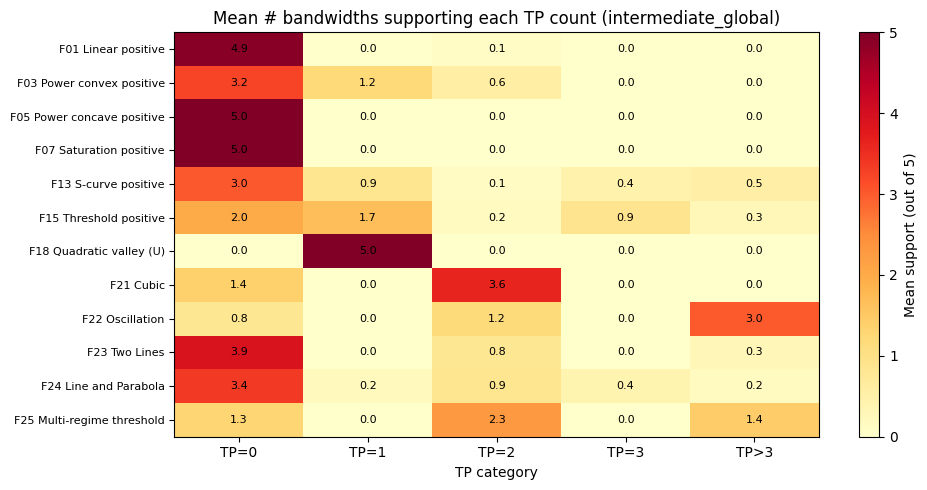

In [366]:
if RUN_METHOD_A:
    # ── TP support diagnostic tables ──
    import matplotlib.pyplot as plt
    
    # ── Table A: Per-family mean TP count at each bandwidth ──
    print('=== Per-bandwidth mean TP count by family ===')
    if len(sizer_bw_df) > 0:
        _bw_tp = sizer_bw_df.pivot_table(
            index='family_id', columns='bw_index', values='tp_count', aggfunc='mean'
        ).round(2)
        _bw_tp.columns = [f'bw_{int(c)}' for c in _bw_tp.columns]
        _bw_tp.insert(0, 'family_name', _bw_tp.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
        display(_bw_tp)
    
    # ── Tables B: Support distribution for each TP category ──
    TP_CATEGORIES = [
        ('n_0tp_bw', 'TP = 0', 'Monotonic (S/Threshold/Saturation…)'),
        ('n_1tp_bw', 'TP = 1', 'U-shape / Spike (F18/F19/F20)'),
        ('n_2tp_bw', 'TP = 2', 'Cubic (F21)'),
        ('n_3tp_bw', 'TP = 3', 'Oscillation / Multi-regime'),
        ('n_gt3tp_bw', 'TP > 3', 'High-frequency oscillation'),
    ]
    
    for col, tp_label, description in TP_CATEGORIES:
        print(f'\n=== {tp_label} support distribution — {description} ===')
        _support = sizer_df.copy()
        _support[col] = _support[col].fillna(0).astype(int)
        
        _sup_table = _support.groupby('family_id')[col].value_counts().unstack(fill_value=0)
        _sup_table = _sup_table.reindex(columns=range(6), fill_value=0)
        _sup_totals = _sup_table.sum(axis=1)
        _sup_out = pd.DataFrame(index=_sup_table.index)
        _sup_out['family_name'] = _sup_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _sup_out['n'] = _sup_totals
        for c in _sup_table.columns:
            _sup_out[f'{c}/5'] = [count_percent(int(n), int(t)) for n, t in zip(_sup_table[c], _sup_totals)]
        display(_sup_out)
    
    # ── Plot: dominant TP heatmap ──
    fig, ax = plt.subplots(figsize=(10, 5))
    tp_cols = ['n_0tp_bw', 'n_1tp_bw', 'n_2tp_bw', 'n_3tp_bw', 'n_gt3tp_bw']
    tp_labels = ['TP=0', 'TP=1', 'TP=2', 'TP=3', 'TP>3']
    _heat = sizer_df.groupby('family_id')[tp_cols].mean()
    _heat.columns = tp_labels
    _heat = _heat.loc[sorted(_heat.index)]
    
    im = ax.imshow(_heat.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(tp_labels)))
    ax.set_xticklabels(tp_labels)
    ax.set_yticks(range(len(_heat.index)))
    fnames = [f'{fid} {FAMILY_CATALOGUE.get(fid, {}).get("name", "")}' for fid in _heat.index]
    ax.set_yticklabels(fnames, fontsize=8)
    for i in range(len(_heat.index)):
        for j in range(len(tp_labels)):
            ax.text(j, i, f'{_heat.values[i, j]:.1f}', ha='center', va='center', fontsize=8)
    ax.set_title(f'Mean # bandwidths supporting each TP count ({MIC_ANALYSIS_GATE})')
    ax.set_xlabel('TP category')
    fig.colorbar(im, ax=ax, label='Mean support (out of 5)')
    plt.tight_layout()

=== Width Ratio Distribution by Family ===
width_ratio_fine = finest bandwidth; width_ratio_mean = mean across all bandwidths



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean,wr_mean_std
family_id,family_name,,,,,,,
F01,Linear positive,155,0.991,0.012,0.956,1.000,0.998,0.003
F03,Power convex positive,78,0.812,0.059,0.694,0.911,0.807,0.052
F05,Power concave positive,77,0.911,0.046,0.828,1.000,0.975,0.018
F07,Saturation positive,582,0.247,0.012,0.217,0.272,0.360,0.006
F13,S-curve positive,114,0.871,0.045,0.778,0.961,0.894,0.032
F15,Threshold positive,99,0.679,0.086,0.444,0.817,0.795,0.058
F18,Quadratic valley (U),173,0.951,0.033,0.856,0.989,0.957,0.012
F21,Cubic,332,0.851,0.042,0.728,0.922,0.879,0.016
F22,Oscillation,153,0.968,0.004,0.961,0.978,0.884,0.020


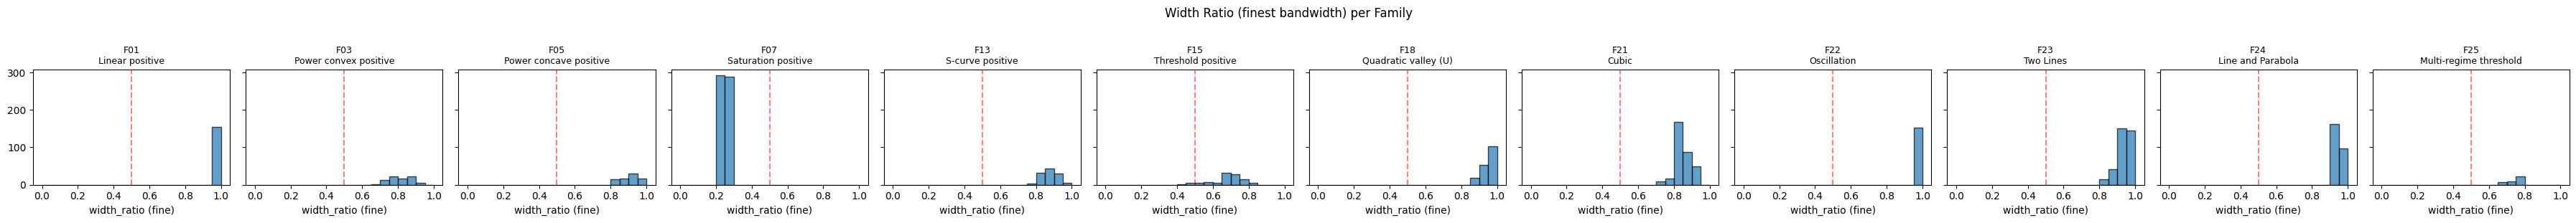

In [367]:
if RUN_METHOD_A:
    # ── Width-ratio diagnostic: distribution per family ──
    print('=== Width Ratio Distribution by Family ===')
    print('width_ratio_fine = finest bandwidth; width_ratio_mean = mean across all bandwidths\n')
    
    wr_summary = sizer_df.groupby(['family_id', 'family_name']).agg(
        n=('case_id', 'size'),
        wr_fine_mean=('width_ratio_fine', 'mean'),
        wr_fine_std=('width_ratio_fine', 'std'),
        wr_fine_min=('width_ratio_fine', 'min'),
        wr_fine_max=('width_ratio_fine', 'max'),
        wr_mean_mean=('width_ratio_mean', 'mean'),
        wr_mean_std=('width_ratio_mean', 'std'),
    ).round(3)
    display(wr_summary)
    
    # Histogram of width_ratio_fine per family
    families = sorted(sizer_df['family_id'].unique())
    n_fam = len(families)
    fig, axes = plt.subplots(1, n_fam, figsize=(3*n_fam, 3), sharey=True)
    if n_fam == 1:
        axes = [axes]
    for ax, fid in zip(axes, families):
        subset = sizer_df[sizer_df['family_id'] == fid]
        fname = subset['family_name'].iloc[0] if len(subset) > 0 else fid
        ax.hist(subset['width_ratio_fine'].dropna(), bins=20, range=(0, 1), alpha=0.7, edgecolor='black')
        ax.set_title(f'{fid}\n{fname}', fontsize=9)
        ax.set_xlabel('width_ratio (fine)')
        ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='0.5 threshold')
    fig.suptitle('Width Ratio (finest bandwidth) per Family', y=1.02)
    plt.tight_layout()
    plt.show()

In [368]:
if RUN_METHOD_A:
    # ── Classification based on dominant TP support ──
    TP_SUPPORT_MIN = 3  # at least 3/5 bandwidths must agree
    
    def tp_classify(row):
        supports = {
            0: row['n_0tp_bw'],
            1: row['n_1tp_bw'],
            2: row['n_2tp_bw'],
            'ge3': row['n_3tp_bw'] + row['n_gt3tp_bw'],
        }
        dominant = max(supports, key=supports.get)
        dominant_n = supports[dominant]
        
        if dominant_n < TP_SUPPORT_MIN:
            return 'Uncertain'
        
        if dominant == 0:
            return 'TP=0'
        elif dominant == 1:
            return 'TP=1'
        elif dominant == 2:
            return 'TP=2'
        else:
            return 'TP\u22653'
    
    sizer_df['sizer_label'] = sizer_df.apply(tp_classify, axis=1)
    
    # ── Expected TP label from catalogue ──
    EXPECTED_TP_LABEL = {}
    for fid, props in FAMILY_CATALOGUE.items():
        tp = props.get('tp', 'N/A')
        mono = props.get('monotonicity', '')
        if tp == 0 and mono == 'monotonic':
            EXPECTED_TP_LABEL[fid] = 'TP=0'
        elif tp == 1:
            EXPECTED_TP_LABEL[fid] = 'TP=1'
        elif tp == 2:
            EXPECTED_TP_LABEL[fid] = 'TP=2'
        elif tp == 'multiple' or (isinstance(tp, int) and tp > 2):
            EXPECTED_TP_LABEL[fid] = 'TP\u22653'
        else:
            EXPECTED_TP_LABEL[fid] = None
    
    # ── Classification table ──
    print(f'=== Multiscale TP classification (dominant TP with \u2265{TP_SUPPORT_MIN}/5 support) ===')
    print(f'Rule: TP=0 | TP=1 | TP=2 | TP\u22653 | <{TP_SUPPORT_MIN}/5\u2192Uncertain\n')
    
    _sc = sizer_df.groupby(['family_id', 'sizer_label']).size().unstack(fill_value=0)
    _sc['total'] = _sc.sum(axis=1)
    
    _col_order = ['TP=0', 'TP=1', 'TP=2', 'TP\u22653', 'Uncertain']
    _display_cols = [c for c in _col_order if c in _sc.columns]
    
    _sc_out = pd.DataFrame(index=_sc.index)
    _sc_out['family_name'] = _sc_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
    _sc_out['Expected'] = _sc_out.index.map(lambda f: EXPECTED_TP_LABEL.get(f, 'N/A'))
    _sc_out['Total'] = [count_percent(n, n) for n in _sc['total']]
    for col in _display_cols:
        _sc_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_sc[col], _sc['total'])]
    
    accuracy = []
    for fid in _sc_out.index:
        exp = EXPECTED_TP_LABEL.get(fid)
        total = int(_sc.loc[fid, 'total'])
        if exp is None:
            accuracy.append('N/A')
        elif exp in _sc.columns:
            n_correct = int(_sc.loc[fid, exp])
            accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
        else:
            accuracy.append(f'0/{total} (0.0%)')
    _sc_out['Accuracy'] = accuracy
    display(_sc_out)
    
    _all = sizer_df.copy()
    _all['_expected'] = _all['family_id'].map(EXPECTED_TP_LABEL)
    _eval = _all[_all['_expected'].notna()].copy()
    if len(_eval) > 0:
        _eval['_correct'] = _eval['sizer_label'] == _eval['_expected']
        n_t = len(_eval)
        n_c = int(_eval['_correct'].sum())
        print(f'\nOverall accuracy (families with expected label): {n_c}/{n_t} ({n_c/n_t:.1%})')

=== Multiscale TP classification (dominant TP with ≥3/5 support) ===
Rule: TP=0 | TP=1 | TP=2 | TP≥3 | <3/5→Uncertain



,family_name,Expected,Total,TP=0,TP=1,TP=2,TP≥3,Uncertain,Accuracy
family_id,,,,,,,,,
F01,Linear positive,TP=0,155 (100.0%),155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),155/155 (100.0%)
F03,Power convex positive,TP=0,78 (100.0%),58 (74.4%),16 (20.5%),0 (0.0%),0 (0.0%),4 (5.1%),58/78 (74.4%)
F05,Power concave positive,TP=0,77 (100.0%),77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),77/77 (100.0%)
F07,Saturation positive,TP=0,582 (100.0%),582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),582/582 (100.0%)
F13,S-curve positive,TP=0,114 (100.0%),84 (73.7%),0 (0.0%),0 (0.0%),0 (0.0%),30 (26.3%),84/114 (73.7%)
F15,Threshold positive,TP=0,99 (100.0%),25 (25.3%),28 (28.3%),0 (0.0%),9 (9.1%),37 (37.4%),25/99 (25.3%)
F18,Quadratic valley (U),TP=1,173 (100.0%),0 (0.0%),173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),173/173 (100.0%)
F21,Cubic,TP=2,332 (100.0%),0 (0.0%),0 (0.0%),332 (100.0%),0 (0.0%),0 (0.0%),332/332 (100.0%)
F22,Oscillation,TP≥3,153 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),153 (100.0%),0 (0.0%),153/153 (100.0%)



Overall accuracy (families with expected label): 1639/2059 (79.6%)


=== Width Ratio Distribution within TP=0 (1546 cases) ===
Goal: separate S-curve (wide derivative) from Threshold (narrow derivative)



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean
family_id,family_name,,,,,,
F01,Linear positive,155,0.991,0.012,0.956,1.000,0.998
F03,Power convex positive,58,0.799,0.059,0.694,0.894,0.793
F05,Power concave positive,77,0.911,0.046,0.828,1.000,0.975
F07,Saturation positive,582,0.247,0.012,0.217,0.272,0.360
F13,S-curve positive,84,0.873,0.050,0.778,0.961,0.895
F15,Threshold positive,25,0.663,0.053,0.550,0.733,0.792
F23,Two Lines,352,0.942,0.038,0.844,0.994,0.984
F24,Line and Parabola,209,0.945,0.020,0.917,0.989,0.975
F25,Multi-regime threshold,4,0.767,0.000,0.767,0.767,0.660


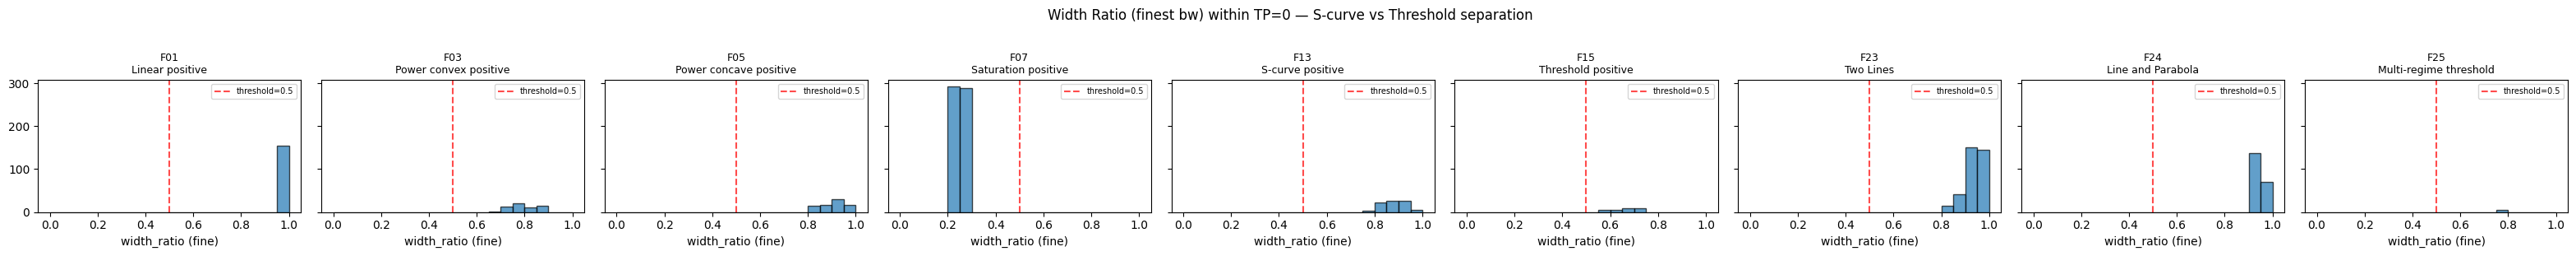

In [369]:
if RUN_METHOD_A:
    # ── Width-ratio diagnostic for TP=0 cases ──
    tp0_df = sizer_df[sizer_df['sizer_label'] == 'TP=0'].copy()
    n_tp0 = len(tp0_df)
    print(f'=== Width Ratio Distribution within TP=0 ({n_tp0} cases) ===')
    print('Goal: separate S-curve (wide derivative) from Threshold (narrow derivative)\n')
    
    if n_tp0 > 0:
        tp0_wr_summary = tp0_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            wr_fine_mean=('width_ratio_fine', 'mean'),
            wr_fine_std=('width_ratio_fine', 'std'),
            wr_fine_min=('width_ratio_fine', 'min'),
            wr_fine_max=('width_ratio_fine', 'max'),
            wr_mean_mean=('width_ratio_mean', 'mean'),
        ).round(3)
        display(tp0_wr_summary)
        
        # Histogram per family within TP=0
        families_tp0 = sorted(tp0_df['family_id'].unique())
        n_fam = len(families_tp0)
        if n_fam > 0:
            fig, axes = plt.subplots(1, n_fam, figsize=(3.5*n_fam, 3), sharey=True)
            if n_fam == 1:
                axes = [axes]
            for ax, fid in zip(axes, families_tp0):
                subset = tp0_df[tp0_df['family_id'] == fid]
                fname = subset['family_name'].iloc[0] if len(subset) > 0 else fid
                ax.hist(subset['width_ratio_fine'].dropna(), bins=20, range=(0, 1),
                        alpha=0.7, edgecolor='black')
                ax.set_title(f'{fid}\n{fname}', fontsize=9)
                ax.set_xlabel('width_ratio (fine)')
                ax.axvline(WIDTH_RATIO_THRESHOLD, color='red', ls='--', alpha=0.7,
                           label=f'threshold={WIDTH_RATIO_THRESHOLD}')
                ax.legend(fontsize=7)
            fig.suptitle('Width Ratio (finest bw) within TP=0 — S-curve vs Threshold separation', y=1.02)
            plt.tight_layout()
            plt.show()
    else:
        print('No TP=0 cases found.')

In [370]:
if RUN_METHOD_A:
    # ── Width-ratio sub-classification within TP=0 ──
    
    tp0_mask = sizer_df['sizer_label'] == 'TP=0'
    n_tp0 = tp0_mask.sum()
    tp0_families = sizer_df.loc[tp0_mask, 'family_id'].unique()
    print(f'TP=0 cases: {n_tp0} across {len(tp0_families)} families')
    
    if USE_WIDTH_RATIO_SUBCLASS and n_tp0 > 0:
        narrow_mask = tp0_mask & (sizer_df['width_ratio_fine'] < WIDTH_RATIO_THRESHOLD)
        n_narrow = narrow_mask.sum()
        n_wide = n_tp0 - n_narrow
        print(f'Width-ratio sub-classification ON (threshold = {WIDTH_RATIO_THRESHOLD})')
        print(f'  wide (wr >= {WIDTH_RATIO_THRESHOLD}): {n_wide} -> keep TP=0')
        print(f'  narrow (wr < {WIDTH_RATIO_THRESHOLD}): {n_narrow} -> relabel Threshold')
        print()
        
        # Apply: relabel narrow TP=0 cases as 'Threshold'
        sizer_df.loc[narrow_mask, 'sizer_label'] = 'Threshold'
        
        # ── Table: only families that had TP=0 cases ──
        _tp0_df = sizer_df[sizer_df['family_id'].isin(tp0_families)].copy()
        _sub = _tp0_df.groupby(['family_id', 'sizer_label']).size().unstack(fill_value=0)
        _sub['total'] = _sub.sum(axis=1)
        
        _col_order = ['TP=0', 'Threshold', 'TP=1', 'TP\u22653', 'Uncertain']
        _sub_display = [c for c in _col_order if c in _sub.columns]
        
        _sub_out = pd.DataFrame(index=_sub.index)
        _sub_out['family_name'] = _sub_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _sub_out['Expected'] = _sub_out.index.map(lambda f: EXPECTED_TP_LABEL.get(f, 'N/A'))
        _sub_out['Total'] = [count_percent(n, n) for n in _sub['total']]
        for col in _sub_display:
            _sub_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_sub[col], _sub['total'])]
        
        accuracy = []
        for fid in _sub_out.index:
            exp = EXPECTED_TP_LABEL.get(fid)
            total = int(_sub.loc[fid, 'total'])
            if exp is None:
                accuracy.append('N/A')
            elif exp in _sub.columns:
                n_correct = int(_sub.loc[fid, exp])
                accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
            else:
                accuracy.append(f'0/{total} (0.0%)')
        _sub_out['Accuracy'] = accuracy
        
        print(f'=== TP=0 sub-classification (wr_fine < {WIDTH_RATIO_THRESHOLD} -> Threshold) ===')
        print(f'Only showing families that had TP=0 cases\n')
        display(_sub_out)
    else:
        print('Width-ratio sub-classification OFF or no TP=0 cases')

TP=0 cases: 1546 across 9 families
Width-ratio sub-classification ON (threshold = 0.5)
  wide (wr >= 0.5): 964 -> keep TP=0
  narrow (wr < 0.5): 582 -> relabel Threshold

=== TP=0 sub-classification (wr_fine < 0.5 -> Threshold) ===
Only showing families that had TP=0 cases



,family_name,Expected,Total,TP=0,Threshold,TP=1,TP≥3,Uncertain,Accuracy
family_id,,,,,,,,,
F01,Linear positive,TP=0,155 (100.0%),155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),155/155 (100.0%)
F03,Power convex positive,TP=0,78 (100.0%),58 (74.4%),0 (0.0%),16 (20.5%),0 (0.0%),4 (5.1%),58/78 (74.4%)
F05,Power concave positive,TP=0,77 (100.0%),77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),77/77 (100.0%)
F07,Saturation positive,TP=0,582 (100.0%),0 (0.0%),582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0/582 (0.0%)
F13,S-curve positive,TP=0,114 (100.0%),84 (73.7%),0 (0.0%),0 (0.0%),0 (0.0%),30 (26.3%),84/114 (73.7%)
F15,Threshold positive,TP=0,99 (100.0%),25 (25.3%),0 (0.0%),28 (28.3%),9 (9.1%),37 (37.4%),25/99 (25.3%)
F23,Two Lines,None,352 (100.0%),352 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),N/A
F24,Line and Parabola,TP=1,260 (100.0%),209 (80.4%),0 (0.0%),0 (0.0%),26 (10.0%),25 (9.6%),0/260 (0.0%)
F25,Multi-regime threshold,TP≥3,36 (100.0%),4 (11.1%),0 (0.0%),0 (0.0%),0 (0.0%),12 (33.3%),0/36 (0.0%)


## Method C — Conditional Dip Test (branch / multimodality detection)

For each x-bin, test whether Y|X is multimodal using Hartigan's dip test.
Persistent bimodality across bins → branching signal (e.g. F23 Two Lines).
Also counts the number of modes per bin via KDE peak detection.

In [371]:
if RUN_METHOD_C:
    from scipy.signal import argrelextrema
    from scipy.stats import gaussian_kde
    try:
        from diptest import diptest as diptest_func
    except ImportError:
        diptest_func = None
        print('WARNING: diptest not installed')

    def conditional_dip_analysis(x, y, n_bins=8, kde_bw='silverman'):
        """Per-bin dip test + KDE mode count on Y|X."""
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 30 or diptest_func is None:
            return None

        bin_edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
        bin_edges[0] -= 1e-10
        bin_idx = np.digitize(x, bin_edges[1:-1])

        bin_results = []
        for b in range(n_bins):
            y_bin = y[bin_idx == b]
            n_bin = len(y_bin)
            if n_bin < 10:
                bin_results.append({
                    'bin': b, 'n': n_bin,
                    'dip_stat': np.nan, 'dip_p': np.nan, 'dip_sig': False,
                    'n_modes': np.nan,
                })
                continue

            dip_stat, dip_p = diptest_func(y_bin)
            dip_sig = dip_p < 0.05

            # KDE mode count
            try:
                kde = gaussian_kde(y_bin, bw_method=kde_bw)
                y_grid = np.linspace(y_bin.min(), y_bin.max(), 200)
                density = kde(y_grid)
                peaks = argrelextrema(density, np.greater, order=5)[0]
                n_modes = max(len(peaks), 1)
            except Exception:
                n_modes = np.nan

            bin_results.append({
                'bin': b, 'n': n_bin,
                'dip_stat': float(dip_stat), 'dip_p': float(dip_p),
                'dip_sig': bool(dip_sig), 'n_modes': int(n_modes) if not np.isnan(n_modes) else np.nan,
            })

        n_sig = sum(1 for r in bin_results if r['dip_sig'])
        frac_sig = n_sig / n_bins
        mode_counts = [r['n_modes'] for r in bin_results if not np.isnan(r['n_modes'])]
        median_modes = float(np.median(mode_counts)) if mode_counts else np.nan

        return {
            'bin_results': bin_results,
            'n_bins': n_bins,
            'n_sig_bins': n_sig,
            'frac_sig': frac_sig,
            'median_modes': median_modes,
        }

    print('Conditional dip test helpers defined.')

Conditional dip test helpers defined.


In [372]:
if RUN_METHOD_C:
    import time as _time

    cond_dip_results = []
    t0 = _time.time()

    for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc='Cond. dip test'):
        pi = int(row['_pt_idx'])
        x = x_all[pi].astype(np.float64)
        y = y_all[pi].astype(np.float64)
        result = conditional_dip_analysis(x, y)

        cid = row['case_id']
        fid = row['family_id']

        if result is not None:
            cond_dip_results.append({
                'case_id': cid, 'family_id': fid,
                'n_sig_bins': result['n_sig_bins'],
                'frac_sig': result['frac_sig'],
                'median_modes': result['median_modes'],
                'is_branch': result['frac_sig'] >= 0.5,
            })
        else:
            cond_dip_results.append({
                'case_id': cid, 'family_id': fid,
                'n_sig_bins': 0, 'frac_sig': 0.0,
                'median_modes': np.nan, 'is_branch': False,
            })

    print(f'Conditional dip test: {len(cond_dip_results):,} cases in {_time.time()-t0:.1f}s')

    cond_dip_df = pd.DataFrame(cond_dip_results)
    cond_dip_df['family_name'] = cond_dip_df['family_id'].map(
        lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')
    )

Cond. dip test: 100%|██████████| 2411/2411 [01:28<00:00, 27.27it/s]

Conditional dip test: 2,411 cases in 88.4s


=== Method C: Conditional Dip Test — Branch Detection ===
Rule: >= 50% of x-bins with dip p<0.05 -> Branch
Also reports median KDE mode count per case



,,n,frac_sig_mean,frac_sig_std,median_modes_mean,n_branch,branch_rate
family_id,family_name,,,,,,
F01,Linear positive,155,0.000,0.000,1.000,0,0 (0.0%)
F03,Power convex positive,78,0.000,0.000,1.000,0,0 (0.0%)
F05,Power concave positive,77,0.006,0.028,1.000,0,0 (0.0%)
F07,Saturation positive,582,0.012,0.038,1.000,0,0 (0.0%)
F13,S-curve positive,114,0.000,0.000,1.000,0,0 (0.0%)
F15,Threshold positive,99,0.014,0.039,1.000,0,0 (0.0%)
F18,Quadratic valley (U),173,0.000,0.000,1.009,0,0 (0.0%)
F21,Cubic,332,0.008,0.031,1.002,0,0 (0.0%)
F22,Oscillation,153,0.000,0.000,1.000,0,0 (0.0%)


,family_name,Expected,Total,Non-branch,Branch,Accuracy
family_id,,,,,,
F01,Linear positive,Non-branch,155 (100.0%),155 (100.0%),0 (0.0%),155/155 (100.0%)
F03,Power convex positive,Non-branch,78 (100.0%),78 (100.0%),0 (0.0%),78/78 (100.0%)
F05,Power concave positive,Non-branch,77 (100.0%),77 (100.0%),0 (0.0%),77/77 (100.0%)
F07,Saturation positive,Non-branch,582 (100.0%),582 (100.0%),0 (0.0%),582/582 (100.0%)
F13,S-curve positive,Non-branch,114 (100.0%),114 (100.0%),0 (0.0%),114/114 (100.0%)
F15,Threshold positive,Non-branch,99 (100.0%),99 (100.0%),0 (0.0%),99/99 (100.0%)
F18,Quadratic valley (U),Non-branch,173 (100.0%),173 (100.0%),0 (0.0%),173/173 (100.0%)
F21,Cubic,Non-branch,332 (100.0%),332 (100.0%),0 (0.0%),332/332 (100.0%)
F22,Oscillation,Non-branch,153 (100.0%),153 (100.0%),0 (0.0%),153/153 (100.0%)



Overall accuracy: 1799/2411 (74.6%)


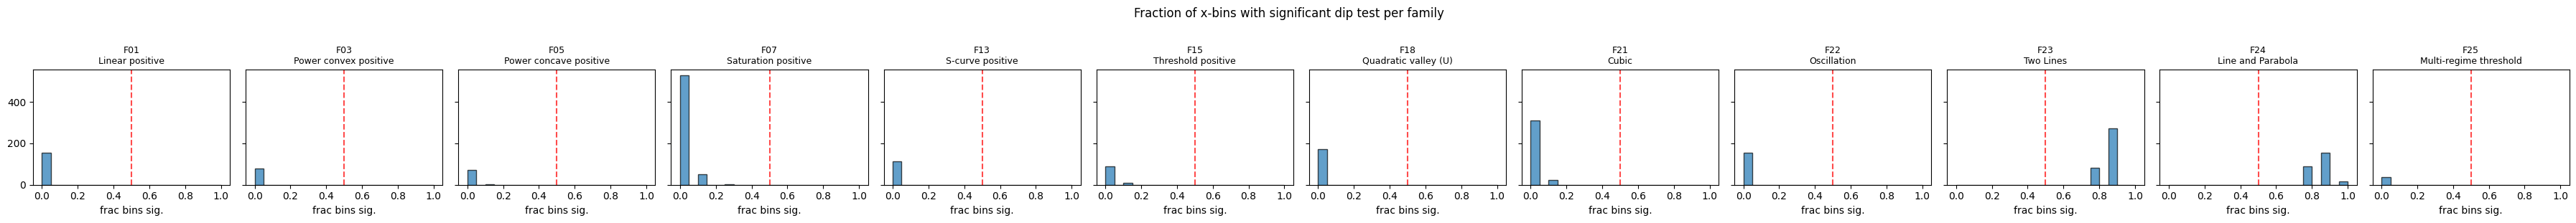

In [373]:
if RUN_METHOD_C:
    import matplotlib.pyplot as plt

    # ── Diagnostic table: per-family summary ──
    BRANCH_FRAC_THRESHOLD = 0.5  # fraction of bins with significant dip -> branch

    print(f'=== Method C: Conditional Dip Test — Branch Detection ===')
    print(f'Rule: >= {BRANCH_FRAC_THRESHOLD:.0%} of x-bins with dip p<0.05 -> Branch')
    print(f'Also reports median KDE mode count per case\n')

    _cd_summary = cond_dip_df.groupby(['family_id', 'family_name']).agg(
        n=('case_id', 'size'),
        frac_sig_mean=('frac_sig', 'mean'),
        frac_sig_std=('frac_sig', 'std'),
        median_modes_mean=('median_modes', 'mean'),
        n_branch=('is_branch', 'sum'),
    )
    _cd_summary['branch_rate'] = _cd_summary.apply(
        lambda r: count_percent(int(r['n_branch']), int(r['n'])), axis=1
    )
    _cd_summary = _cd_summary.round(3)
    display(_cd_summary)

    # ── Classification table (same format as Method A) ──
    cond_dip_df['cond_dip_label'] = np.where(cond_dip_df['is_branch'], 'Branch', 'Non-branch')

    _cd_ct = cond_dip_df.groupby(['family_id', 'cond_dip_label']).size().unstack(fill_value=0)
    _cd_ct['total'] = _cd_ct.sum(axis=1)

    _cd_col_order = ['Non-branch', 'Branch']
    _cd_display = [c for c in _cd_col_order if c in _cd_ct.columns]

    _cd_out = pd.DataFrame(index=_cd_ct.index)
    _cd_out['family_name'] = _cd_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))

    EXPECTED_BRANCH = {}
    for fid, props in FAMILY_CATALOGUE.items():
        if props.get('special_shape', '') in ('two_lines', 'multi_branch'):
            EXPECTED_BRANCH[fid] = 'Branch'
        else:
            EXPECTED_BRANCH[fid] = 'Non-branch'

    _cd_out['Expected'] = _cd_out.index.map(lambda f: EXPECTED_BRANCH.get(f, 'N/A'))
    _cd_out['Total'] = [count_percent(n, n) for n in _cd_ct['total']]
    for col in _cd_display:
        _cd_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_cd_ct[col], _cd_ct['total'])]

    accuracy = []
    for fid in _cd_out.index:
        exp = EXPECTED_BRANCH.get(fid)
        total = int(_cd_ct.loc[fid, 'total'])
        if exp is None or exp not in _cd_ct.columns:
            accuracy.append('N/A')
        else:
            n_correct = int(_cd_ct.loc[fid, exp])
            accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
    _cd_out['Accuracy'] = accuracy
    display(_cd_out)

    # Overall accuracy
    cond_dip_df['_expected'] = cond_dip_df['family_id'].map(EXPECTED_BRANCH)
    _eval_c = cond_dip_df[cond_dip_df['_expected'].notna()].copy()
    if len(_eval_c) > 0:
        _eval_c['_correct'] = _eval_c['cond_dip_label'] == _eval_c['_expected']
        n_tc = len(_eval_c)
        n_cc = int(_eval_c['_correct'].sum())
        print(f'\nOverall accuracy: {n_cc}/{n_tc} ({n_cc/n_tc:.1%})')

    # ── Histogram: frac_sig per family ──
    families_c = sorted(cond_dip_df['family_id'].unique())
    n_fam = len(families_c)
    if n_fam > 0:
        fig, axes = plt.subplots(1, n_fam, figsize=(3*n_fam, 3), sharey=True)
        if n_fam == 1:
            axes = [axes]
        for ax, fid in zip(axes, families_c):
            subset = cond_dip_df[cond_dip_df['family_id'] == fid]
            fname = subset['family_name'].iloc[0] if len(subset) > 0 else fid
            ax.hist(subset['frac_sig'].dropna(), bins=20, range=(0, 1),
                    alpha=0.7, edgecolor='black')
            ax.set_title(f'{fid}\n{fname}', fontsize=9)
            ax.set_xlabel('frac bins sig.')
            ax.axvline(BRANCH_FRAC_THRESHOLD, color='red', ls='--', alpha=0.7)
        fig.suptitle('Fraction of x-bins with significant dip test per family', y=1.02)
        plt.tight_layout()
        plt.show()

## Method B — KL / QR / HD (distributional tests)

From: *"Thresholds for ecological responses to global change do not emerge from empirical data"*

- **KL**: Does the overall distribution of Y change with X? (permutation test on Y)
- **QR**: Does the spread of the Y distribution change substantially with X? (permutation test on X)
- **HD**: Does Y have multiple modes / two distinct states? (Hartigan's dip test)

Decision rule:
- KL+, QR+, HD+ → Threshold
- KL+, QR+, HD− → Cubic
- otherwise → S-shaped

In [ ]:
if RUN_METHOD_B:
    # ── KL / QR / HD implementation (Hillebrand et al. 2020) ──
    from scipy.stats import gaussian_kde
    from diptest import diptest as diptest_func

    def _conditional_density(x, y, n_grid_x=30, n_grid_y=50):
        """Compute conditional P(Y|X=gx) via 2D KDE, following Hillebrand et al. 2020.

        Returns: gx, gy, p_cond[ix, iy], p_marginal_y[iy], p_x[ix]
        """
        gx = np.linspace(x.min(), x.max(), n_grid_x)
        gy = np.linspace(y.min(), y.max(), n_grid_y)
        GX, GY = np.meshgrid(gx, gy, indexing='ij')
        grid_pts = np.vstack([GX.ravel(), GY.ravel()])

        # 2D KDE
        try:
            kde2d = gaussian_kde(np.vstack([x, y]), bw_method='silverman')
            density_2d = kde2d(grid_pts).reshape(n_grid_x, n_grid_y)
        except np.linalg.LinAlgError:
            return None

        # P(X) via 1D KDE
        kde_x = gaussian_kde(x, bw_method='silverman')
        p_x = kde_x(gx)
        p_x = p_x / p_x.sum()

        # Conditional P(Y|X=gx) = density_2d(gx, gy) / integral over gy
        p_cond = np.zeros_like(density_2d)
        for ix in range(n_grid_x):
            col_sum = density_2d[ix].sum()
            if col_sum > 1e-20:
                p_cond[ix] = density_2d[ix] / col_sum
            else:
                p_cond[ix] = 1.0 / n_grid_y

        # Marginal P(Y) via 1D KDE
        kde_y = gaussian_kde(y, bw_method='silverman')
        p_marginal_y = kde_y(gy)
        p_marginal_y = p_marginal_y / p_marginal_y.sum()

        return gx, gy, p_cond, p_marginal_y, p_x

    def _kl_from_cond(p_cond, p_marginal_y, p_x):
        """KL = sum_gx P(X=gx) * KL(P(Y|X=gx) || P(Y))"""
        n_grid_x = p_cond.shape[0]
        kl = 0.0
        for ix in range(n_grid_x):
            pc = p_cond[ix]
            # Avoid log(0): add small epsilon
            pc_safe = np.maximum(pc, 1e-20)
            pm_safe = np.maximum(p_marginal_y, 1e-20)
            kl += p_x[ix] * np.sum(pc_safe * np.log(pc_safe / pm_safe))
        return float(kl)

    def _qr_from_cond(p_cond, gy):
        """QR = Q99(IQR) / Q01(IQR), where IQR = Q95(Y|X) - Q05(Y|X) per gx.
        Following Hillebrand et al. 2020 eq. (4)."""
        n_grid_x = p_cond.shape[0]
        iqrs = []
        for ix in range(n_grid_x):
            cdf = np.cumsum(p_cond[ix])
            cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
            q05 = gy[np.searchsorted(cdf, 0.05)]
            q95 = gy[np.searchsorted(cdf, 0.95, side='right').clip(max=len(gy)-1)]
            iqrs.append(q95 - q05)
        iqrs = np.array(iqrs)
        q01_iqr = np.percentile(iqrs, 1)
        q99_iqr = np.percentile(iqrs, 99)
        if q01_iqr < 1e-10:
            return np.nan
        return float(q99_iqr / q01_iqr)

    def kl_test(x, y, n_perm=199):
        """KL divergence test (paper-style): 2D KDE conditional density + permutation."""
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        if len(x) < 20:
            return np.nan, np.nan
        result = _conditional_density(x, y)
        if result is None:
            return np.nan, np.nan
        gx, gy, p_cond, p_marginal_y, p_x = result
        kl_obs = _kl_from_cond(p_cond, p_marginal_y, p_x)

        count = 0
        rng = np.random.RandomState(42)
        for _ in range(n_perm):
            y_perm = rng.permutation(y)
            res_perm = _conditional_density(x, y_perm)
            if res_perm is None:
                continue
            _, _, pc_perm, pm_perm, px_perm = res_perm
            kl_perm = _kl_from_cond(pc_perm, pm_perm, px_perm)
            if kl_perm >= kl_obs:
                count += 1
        return kl_obs, float((count + 1) / (n_perm + 1))

    def qr_test(x, y, n_perm=199):
        """QR test (paper-style): IQR 99%/1% quantile ratio + permutation."""
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        if len(x) < 20:
            return np.nan, np.nan
        result = _conditional_density(x, y)
        if result is None:
            return np.nan, np.nan
        gx, gy, p_cond, p_marginal_y, p_x = result
        qr_obs = _qr_from_cond(p_cond, gy)
        if np.isnan(qr_obs):
            return np.nan, np.nan

        count = 0
        rng = np.random.RandomState(42)
        for _ in range(n_perm):
            y_perm = rng.permutation(y)
            res_perm = _conditional_density(x, y_perm)
            if res_perm is None:
                continue
            _, gy_perm, pc_perm, _, _ = res_perm
            qr_perm = _qr_from_cond(pc_perm, gy_perm)
            if not np.isnan(qr_perm) and qr_perm >= qr_obs:
                count += 1
        return qr_obs, float((count + 1) / (n_perm + 1))

    def hd_test(y):
        """Hartigan's dip test for multimodality."""
        valid = np.isfinite(y)
        y = y[valid]
        if len(y) < 20:
            return np.nan, np.nan
        dip, pval = diptest_func(y)
        return float(dip), float(pval)

    print('KL / QR / HD helpers defined (paper-style: 2D KDE + IQR 99/1 ratio).')

In [375]:
if RUN_METHOD_B:
    # ── Run KL / QR / HD on Complex-path cases ──
    np.random.seed(42)
    
    klqrhd_results = []
    t0 = time.time()
    
    for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc='KL/QR/HD'):
        pi = int(row['_pt_idx'])
        x = x_all[pi].astype(np.float64)
        y = y_all[pi].astype(np.float64)
        
        kl_stat, kl_p = kl_test(x, y)
        qr_stat, qr_p = qr_test(x, y)
        hd_stat, hd_p = hd_test(y)
        
        klqrhd_results.append({
            'case_id': row['case_id'],
            'family_id': row['family_id'],
            'kl_stat': kl_stat, 'kl_p': kl_p, 'kl_sig': kl_p < 0.05 if not np.isnan(kl_p) else np.nan,
            'qr_stat': qr_stat, 'qr_p': qr_p, 'qr_sig': qr_p < 0.05 if not np.isnan(qr_p) else np.nan,
            'hd_stat': hd_stat, 'hd_p': hd_p, 'hd_sig': hd_p < 0.05 if not np.isnan(hd_p) else np.nan,
        })
    
    print(f'KL/QR/HD: {len(klqrhd_results):,} cases in {time.time()-t0:.1f}s')
    
    klqrhd_df = pd.DataFrame(klqrhd_results)
    klqrhd_df['family_name'] = klqrhd_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
    
    # Significance rates per family
    print('\n=== Significance rates per family ===')
    _sig = klqrhd_df.groupby(['family_id', 'family_name']).agg(
        n=('case_id', 'size'),
        KL_sig=('kl_sig', lambda s: count_percent(int(s.sum()), len(s))),
        QR_sig=('qr_sig', lambda s: count_percent(int(s.sum()), len(s))),
        HD_sig=('hd_sig', lambda s: count_percent(int(s.sum()), len(s))),
    )
    display(_sig)

KL/QR/HD:  11%|█         | 261/2411 [00:23<03:13, 11.13it/s]


KeyboardInterrupt: 

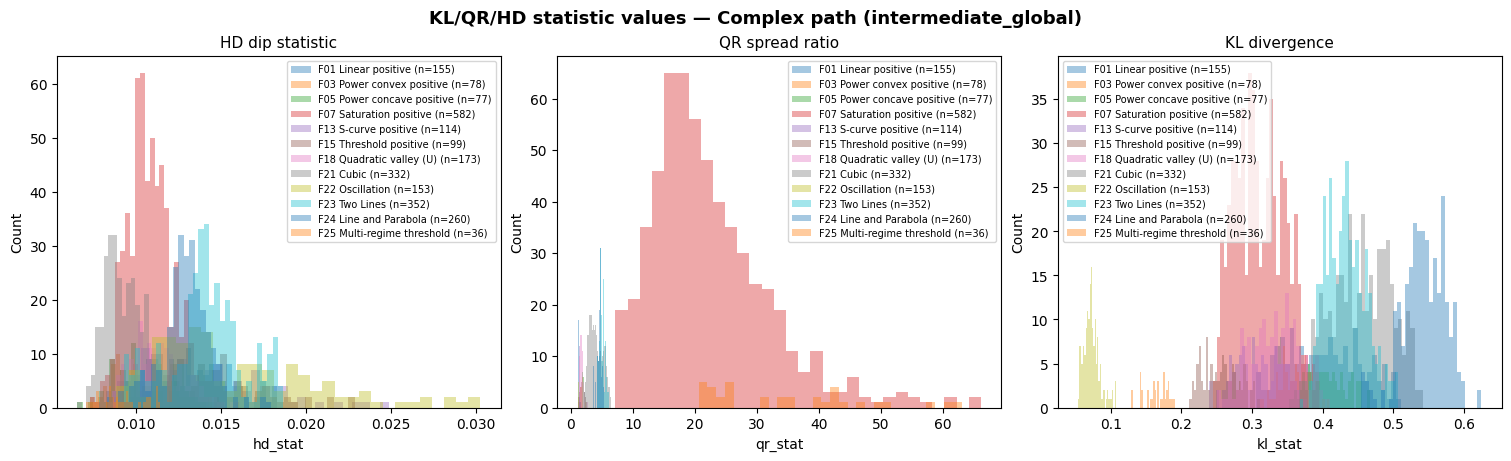


=== HD dip statistic per family (key for S vs Threshold) ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,155.0,0.0129,0.0025,0.0082,0.0098,0.0110,0.0128,0.0147,0.0163,0.0183
F03,Power convex positive,78.0,0.0099,0.0016,0.0073,0.0082,0.0088,0.0097,0.0105,0.0120,0.0150
F05,Power concave positive,77.0,0.0104,0.0018,0.0066,0.0085,0.0092,0.0100,0.0115,0.0131,0.0160
F07,Saturation positive,582.0,0.0108,0.0013,0.0073,0.0092,0.0100,0.0107,0.0116,0.0126,0.0161
F13,S-curve positive,114.0,0.0142,0.0033,0.0087,0.0105,0.0114,0.0138,0.0163,0.0184,0.0249
F15,Threshold positive,99.0,0.0147,0.0027,0.0103,0.0118,0.0125,0.0142,0.0161,0.0182,0.0229
F18,Quadratic valley (U),173.0,0.0114,0.0016,0.0084,0.0094,0.0102,0.0113,0.0123,0.0136,0.0160
F21,Cubic,332.0,0.0096,0.0014,0.0066,0.0081,0.0085,0.0093,0.0105,0.0114,0.0145
F22,Oscillation,153.0,0.0159,0.0047,0.0088,0.0112,0.0123,0.0144,0.0189,0.0222,0.0303



=== QR spread ratio per family ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,155.0,1.2208,0.0944,1.0724,1.0902,1.1508,1.2171,1.2735,1.3490,1.4980
F03,Power convex positive,78.0,1.7735,0.2119,1.4339,1.5429,1.5974,1.7684,1.8751,1.9701,2.4623
F05,Power concave positive,77.0,1.9795,0.2598,1.3243,1.5769,1.8805,1.9842,2.1351,2.2945,2.5410
F07,Saturation positive,582.0,22.3679,9.6218,7.1672,12.3726,15.6960,20.3580,27.2068,34.4393,66.1162
F13,S-curve positive,114.0,1.3557,0.1204,1.0782,1.1955,1.3036,1.3657,1.4411,1.4913,1.6035
F15,Threshold positive,99.0,1.5835,0.1509,1.2092,1.3771,1.4760,1.5999,1.6980,1.7634,1.8510
F18,Quadratic valley (U),173.0,1.7371,0.3177,1.2495,1.3663,1.5003,1.6910,1.8877,2.2012,2.7179
F21,Cubic,332.0,4.0419,1.0479,2.1488,2.7615,3.1622,3.8955,4.8802,5.5733,6.4360
F22,Oscillation,153.0,1.1849,0.0485,1.0904,1.1270,1.1498,1.1767,1.2182,1.2526,1.3036


In [351]:
if RUN_METHOD_B:
    # ── KL/QR/HD statistic VALUE distributions (not just significance) ──
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
    
    stat_cols = [
        ('hd_stat', 'HD dip statistic'),
        ('qr_stat', 'QR spread ratio'),
        ('kl_stat', 'KL divergence'),
    ]
    
    for ax, (col, title) in zip(axes, stat_cols):
        for fid in sorted(klqrhd_df['family_id'].unique()):
            vals = klqrhd_df.loc[klqrhd_df['family_id'] == fid, col].dropna()
            if len(vals) == 0:
                continue
            fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
            ax.hist(vals, bins=30, alpha=0.4, label=f'{fid} {fname} (n={len(vals)})')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend(fontsize=7)
    
    fig.suptitle(f'KL/QR/HD statistic values — Complex path ({MIC_ANALYSIS_GATE})', fontsize=13, fontweight='bold')
    plt.show()
    
    # ── Summary table: stat value percentiles per family ──
    print('\n=== HD dip statistic per family (key for S vs Threshold) ===')
    _hd_summary = klqrhd_df.groupby('family_id')['hd_stat'].describe(percentiles=[.1,.25,.5,.75,.9]).round(4)
    _hd_summary.insert(0, 'family_name', _hd_summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
    display(_hd_summary)
    
    print('\n=== QR spread ratio per family ===')
    _qr_summary = klqrhd_df.groupby('family_id')['qr_stat'].describe(percentiles=[.1,.25,.5,.75,.9]).round(4)
    _qr_summary.insert(0, 'family_name', _qr_summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
    display(_qr_summary)

In [352]:
if RUN_METHOD_B:
    # ── KL/QR/HD classification ──
    # Step 1: HD significance → Cubic vs S/Threshold
    #   HD- (not significant) → Cubic
    #   HD+ (significant)     → S/Threshold candidate
    # Step 2: Among S/Threshold, use HD dip value to separate
    #   Higher dip → Threshold (Y is more clearly bimodal: two distinct states)
    #   Lower dip  → S-curve (Y transitions gradually, less bimodal)
    
    HD_DIP_THRESHOLD = 0.02  # tune based on distribution above
    
    def klqrhd_classify(row):
        if any(np.isnan([row.get('kl_sig', np.nan), row.get('qr_sig', np.nan), row.get('hd_sig', np.nan)])):
            return 'failed'
        
        # Step 1: Cubic detection via HD
        if row['kl_sig'] and row['qr_sig'] and not row['hd_sig']:
            return 'Cubic'
        
        # Step 2: S vs Threshold via HD dip value
        hd_val = row.get('hd_stat', np.nan)
        if np.isnan(hd_val):
            return 'S/Threshold'
        
        if hd_val >= HD_DIP_THRESHOLD:
            return 'Threshold'
        else:
            return 'S-curve'
    
    klqrhd_df['klqrhd_label'] = klqrhd_df.apply(klqrhd_classify, axis=1)
    
    # ── Classification table ──
    print(f'=== KL/QR/HD classification (HD_DIP_THRESHOLD={HD_DIP_THRESHOLD}) ===')
    print(f'Rule: HD- → Cubic | HD+ & dip≥{HD_DIP_THRESHOLD} → Threshold | HD+ & dip<{HD_DIP_THRESHOLD} → S-curve\n')
    
    _kc = klqrhd_df.groupby(['family_id', 'klqrhd_label']).size().unstack(fill_value=0)
    _kc['total'] = _kc.sum(axis=1)
    _kc_out = pd.DataFrame(index=_kc.index)
    _kc_out['family_name'] = _kc_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
    _kc_out['Total'] = [count_percent(n, n) for n in _kc['total']]
    for col in sorted(_kc.columns.drop('total')):
        _kc_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_kc[col], _kc['total'])]
    
    # Expected labels
    EXPECTED_KLQRHD = {}
    for fid, props in FAMILY_CATALOGUE.items():
        shape = props.get('special_shape', '')
        if 'S-curve' in shape:
            EXPECTED_KLQRHD[fid] = 'S-curve'
        elif 'threshold' in shape.lower() and 'windowed' not in shape.lower():
            EXPECTED_KLQRHD[fid] = 'Threshold'
        elif 'cubic' in shape:
            EXPECTED_KLQRHD[fid] = 'Cubic'
        else:
            EXPECTED_KLQRHD[fid] = None
    
    _kc_out['Expected'] = _kc_out.index.map(lambda f: EXPECTED_KLQRHD.get(f, 'N/A'))
    accuracy = []
    for fid in _kc_out.index:
        exp = EXPECTED_KLQRHD.get(fid)
        total = int(_kc.loc[fid, 'total'])
        if exp is None or exp not in _kc.columns:
            accuracy.append('N/A')
        else:
            n_correct = int(_kc.loc[fid, exp])
            accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
    _kc_out['Accuracy'] = accuracy
    display(_kc_out)
    
    # F13/F15/F21 summary
    _target = klqrhd_df[klqrhd_df['family_id'].isin(['F13', 'F15', 'F21'])].copy()
    if len(_target) > 0:
        _target['_expected'] = _target['family_id'].map(EXPECTED_KLQRHD)
        _target['_correct'] = _target['klqrhd_label'] == _target['_expected']
        n_t = len(_target)
        n_c = int(_target['_correct'].sum())
        print(f'\nF13/F15/F21 accuracy: {n_c}/{n_t} ({n_c/n_t:.1%})')
        
        # Merged S/Threshold accuracy
        _target['_label_merged'] = _target['klqrhd_label'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
        _target['_expected_merged'] = _target['_expected'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
        n_cm = int((_target['_label_merged'] == _target['_expected_merged']).sum())
        print(f'F13/F15/F21 accuracy (S/T merged): {n_cm}/{n_t} ({n_cm/n_t:.1%})')

=== KL/QR/HD classification (HD_DIP_THRESHOLD=0.02) ===
Rule: HD- → Cubic | HD+ & dip≥0.02 → Threshold | HD+ & dip<0.02 → S-curve



,family_name,Total,Cubic,S-curve,Threshold,Expected,Accuracy
family_id,,,,,,,
F01,Linear positive,155 (100.0%),28 (18.1%),127 (81.9%),0 (0.0%),None,N/A
F03,Power convex positive,78 (100.0%),78 (100.0%),0 (0.0%),0 (0.0%),None,N/A
F05,Power concave positive,77 (100.0%),74 (96.1%),3 (3.9%),0 (0.0%),None,N/A
F07,Saturation positive,582 (100.0%),582 (100.0%),0 (0.0%),0 (0.0%),None,N/A
F13,S-curve positive,114 (100.0%),82 (71.9%),31 (27.2%),1 (0.9%),S-curve,31/114 (27.2%)
F15,Threshold positive,99 (100.0%),91 (91.9%),8 (8.1%),0 (0.0%),Threshold,0/99 (0.0%)
F18,Quadratic valley (U),173 (100.0%),164 (94.8%),9 (5.2%),0 (0.0%),None,N/A
F21,Cubic,332 (100.0%),332 (100.0%),0 (0.0%),0 (0.0%),Cubic,332/332 (100.0%)
F22,Oscillation,153 (100.0%),2 (1.3%),124 (81.0%),27 (17.6%),None,N/A



F13/F15/F21 accuracy: 363/545 (66.6%)
F13/F15/F21 accuracy (S/T merged): 372/545 (68.3%)


## S-curve vs Threshold separation

Within non-Cubic cases (SiZer S/Threshold), use KL/QR/HD **statistic values** (not significance) to separate:
- **HD dip value**: Threshold has more clearly bimodal Y → larger dip
- **QR spread ratio**: Threshold has sharper spread change → larger ratio
- **SiZer width ratio**: S-curve has wider derivative region → larger width ratio

In [353]:
if RUN_METHOD_A and RUN_METHOD_B:
    # ── S vs Threshold: statistic value distributions ──
    import matplotlib.pyplot as plt
    
    # Merge SiZer + KL/QR/HD results
    _st_merge = sizer_df[['case_id', 'family_id', 'family_name', 'sizer_label']].merge(
        klqrhd_df[['case_id', 'hd_stat', 'qr_stat', 'hd_sig', 'qr_sig']], on='case_id', how='inner'
    )
    
    # Focus on S/Threshold cases (non-Cubic by SiZer) that are F13 or F15
    _st_focus = _st_merge[
        (_st_merge['family_id'].isin(['F13', 'F15'])) &
        (_st_merge['sizer_label'] == 'S/Threshold')
    ].copy()
    
    print(f'S/Threshold cases for F13/F15: {len(_st_focus)}')
    print(f'  F13 S-curve: {(_st_focus["family_id"]=="F13").sum()}')
    print(f'  F15 Threshold: {(_st_focus["family_id"]=="F15").sum()}')
    
    if len(_st_focus) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
        
        indicators = [
            ('hd_stat', 'HD dip statistic', 'Threshold should be higher (bimodal Y)'),
            ('qr_stat', 'QR spread ratio', 'Threshold should be higher (sharp spread change)'),
        ]
        
        for ax, (col, title, note) in zip(axes, indicators):
            for fid, color, label in [('F13', 'steelblue', 'F13 S-curve'), ('F15', 'coral', 'F15 Threshold')]:
                vals = _st_focus.loc[_st_focus['family_id'] == fid, col].dropna()
                ax.hist(vals, bins=30, alpha=0.5, color=color, label=f'{label} (n={len(vals)})')
            ax.set_title(f'{title}\n({note})', fontsize=9)
            ax.set_xlabel(col)
            ax.set_ylabel('Count')
            ax.legend(fontsize=8)
        
        fig.suptitle(f'S-curve vs Threshold statistic distributions ({MIC_ANALYSIS_GATE})', fontsize=12)
        plt.show()
        
        # Summary table
        print('\n=== Statistic value summary: F13 vs F15 ===')
        _summary = _st_focus.groupby('family_id').agg(
            n=('case_id', 'size'),
            hd_dip_median=('hd_stat', 'median'),
            hd_dip_mean=('hd_stat', 'mean'),
            qr_ratio_median=('qr_stat', 'median'),
            qr_ratio_mean=('qr_stat', 'mean'),
        ).round(4)
        _summary.insert(0, 'family_name', _summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
        display(_summary)
    else:
        print('No S/Threshold cases for F13/F15.')

S/Threshold cases for F13/F15: 0
  F13 S-curve: 0
  F15 Threshold: 0
No S/Threshold cases for F13/F15.


In [354]:
if RUN_METHOD_A and RUN_METHOD_B:
    # ── S vs Threshold classification attempt ──
    # Try different indicators to separate F13 S-curve from F15 Threshold
    
    if len(_st_focus) > 0:
        results = []
        
        for col, name, direction in [
            ('hd_stat', 'HD dip', 'high_is_threshold'),
            ('qr_stat', 'QR ratio', 'high_is_threshold'),
        ]:
            vals = _st_focus[col].dropna()
            if len(vals) == 0:
                continue
            
            # Sweep thresholds, find best accuracy
            thresholds = np.percentile(vals, np.arange(10, 91, 5))
            best_thr_acc = 0
            best_thr = 0
            
            for thr in thresholds:
                if direction == 'high_is_threshold':
                    pred = np.where(_st_focus[col] >= thr, 'Threshold', 'S-curve')
                else:
                    pred = np.where(_st_focus[col] >= thr, 'S-curve', 'Threshold')
                
                truth = _st_focus['family_id'].map({'F13': 'S-curve', 'F15': 'Threshold'})
                acc = (pred == truth).mean()
                if acc > best_thr_acc:
                    best_thr_acc = acc
                    best_thr = thr
            
            results.append({
                'Indicator': name,
                'Best threshold': f'{best_thr:.4f}',
                'Accuracy': f'{best_thr_acc:.1%}',
                'Direction': direction,
            })
        
        print('=== S vs Threshold: best single-indicator classification ===')
        display(pd.DataFrame(results))
    else:
        print('No data to evaluate.')

No data to evaluate.


## Head-to-head comparison

Merge SiZer and KL/QR/HD results and compare accuracy per family.

In [355]:
if RUN_METHOD_A and RUN_METHOD_B:
    # ── Comparison: Multiscale TP vs KL/QR/HD ──
    compare = sizer_df[['case_id', 'family_id', 'family_name', 'sizer_label']].merge(
        klqrhd_df[['case_id', 'klqrhd_label', 'hd_stat', 'qr_stat']], on='case_id', how='outer'
    )
    
    compare['expected_tp'] = compare['family_id'].map(EXPECTED_TP_LABEL)
    compare['tp_correct'] = compare['sizer_label'] == compare['expected_tp']
    
    compare['expected_klqrhd'] = compare['family_id'].map(EXPECTED_KLQRHD)
    compare['klqrhd_correct'] = compare['klqrhd_label'] == compare['expected_klqrhd']
    compare['klqrhd_merged'] = compare['klqrhd_label'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
    compare['expected_merged'] = compare['expected_klqrhd'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
    compare['klqrhd_correct_merged'] = compare['klqrhd_merged'] == compare['expected_merged']
    
    rows = []
    for fid in sorted(compare['family_id'].unique()):
        sub = compare[compare['family_id'] == fid]
        fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
        n = len(sub)
        exp_tp = EXPECTED_TP_LABEL.get(fid)
        
        if exp_tp is not None:
            tc = int(sub['tp_correct'].sum())
            tp_acc = f'{tc}/{n} ({tc/n:.1%})'
        else:
            tp_acc = 'N/A'
        
        exp_kl = EXPECTED_KLQRHD.get(fid)
        if exp_kl is not None:
            kc = int(sub['klqrhd_correct'].sum())
            kcm = int(sub['klqrhd_correct_merged'].sum())
            kl_acc = f'{kc}/{n} ({kc/n:.1%})'
            kl_acc_m = f'{kcm}/{n} ({kcm/n:.1%})'
        else:
            kl_acc = 'N/A'
            kl_acc_m = 'N/A'
        
        rows.append({
            'Family': f'{fid} {fname}',
            'n': n,
            'Expected (TP)': exp_tp or 'N/A',
            'Multiscale TP': tp_acc,
            'KL/QR/HD (3-way)': kl_acc,
            'KL/QR/HD (S/T merged)': kl_acc_m,
        })
    
    # Overall for families with expected TP label
    _eval = compare[compare['expected_tp'].notna()]
    if len(_eval) > 0:
        n_t = len(_eval)
        tc_t = int(_eval['tp_correct'].sum())
        rows.append({
            'Family': 'Overall (with expected)',
            'n': n_t,
            'Expected (TP)': '',
            'Multiscale TP': f'{tc_t}/{n_t} ({tc_t/n_t:.1%})',
            'KL/QR/HD (3-way)': 'N/A',
            'KL/QR/HD (S/T merged)': 'N/A',
        })
    
    print('=== Comparison: Multiscale TP vs KL/QR/HD ===')

=== Comparison: Multiscale TP vs KL/QR/HD ===
